# Adversarial-Deconfounding Drug Response Model — Plate Adversary

This is the plate-resolved sibling of `7_adae_model.ipynb`. The split, predictor
head, and dynamic-λ machinery are unchanged; the two things that move are:

- **Example grain.** The training bundle is built at `(cell_line, drug, concentration, unit, plate)` by
  `3.5_Make_plate_tensors.ipynb`, so plate identity actually reaches the target Δ rather than being
  averaged out in the pseudobulk aggregate.
- **Adversary target.** The Gradient Reversal Layer now attacks `z_fused` (the representation the
  predictor sees) with the **plate** label, not `z_drug` with the cell-line label. `z_drug` carries
  no cell-line signal under drug_blind by construction, so the notebook 7 adversary was vacuous
  there; `z_fused` is the latent whose plate-invariance we actually care about.

See `AD_AE_ARCHITECTURE_CONTEXT.md` and the project plan for the design rationale. The dynamic-λ
rule `λ_t = clamp(α · EMA(MSE_std) / EMA(CE), λ_min, λ_max)` is unchanged; only which CE you feed it
changes.


## Hyperparameters

In [1]:
from pathlib import Path

SPLIT_MODE = "drug_blind"  # one of {"drug_blind", "mixed"}; "tumor_blind" is rejected below
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
BATCH_SIZE = 512
RANDOM_SEED = 42
NUM_WORKERS = 0

MODEL_NAME = "adae"
CTX_BRANCH_HIDDEN_DIMS = (1024, 512)
DRUG_BRANCH_HIDDEN_DIMS = (512, 256)
Z_CTX_DIM = 96
Z_DRUG_DIM = 96
FUSED_HIDDEN_DIMS = (512, 256)
PREDICTOR_HIDDEN_DIMS = (512,)
ADV_HIDDEN_DIMS = (100, 100)
CONFOUNDER_COLUMN = "plate"
FUSER_TYPE = "film"
ADVERSARY_CONDITIONING = "drug"

ALPHA_TARGET = 0.1
EMA_MOMENTUM = 0.99
LAMBDA_MIN = 1e-3
LAMBDA_MAX = 10.0

TARGET_MODE = "delta"
PREPROCESS_BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MONITOR = "val_treated_cosine"
EARLY_STOPPING_MODE = "max"
ACCELERATOR = "auto"
DEVICES = 1
PRECISION = "32-true"

PLOT_TEST_SAMPLE_COUNT = 50
PLOT_TEST_SAMPLE_STRATEGY = "seeded_random"
PLOT_RANDOM_SEED = RANDOM_SEED
EMBEDDING_METHOD = "pca"
N_EMBEDDING_COMPONENTS = 2

TENSOR_ARTIFACTS_DIR = Path("data/Tahoe100M_tensor_artifacts_L1000_plate")
LIGHTNING_OUTPUT_DIR = Path("artifacts/lightning/adae_plate")

run_config = {
    "SPLIT_MODE": SPLIT_MODE,
    "SPLIT_FRACTIONS": SPLIT_FRACTIONS,
    "BATCH_SIZE": BATCH_SIZE,
    "RANDOM_SEED": RANDOM_SEED,
    "NUM_WORKERS": NUM_WORKERS,
    "MODEL_NAME": MODEL_NAME,
    "CTX_BRANCH_HIDDEN_DIMS": CTX_BRANCH_HIDDEN_DIMS,
    "DRUG_BRANCH_HIDDEN_DIMS": DRUG_BRANCH_HIDDEN_DIMS,
    "Z_CTX_DIM": Z_CTX_DIM,
    "Z_DRUG_DIM": Z_DRUG_DIM,
    "FUSED_HIDDEN_DIMS": FUSED_HIDDEN_DIMS,
    "PREDICTOR_HIDDEN_DIMS": PREDICTOR_HIDDEN_DIMS,
    "ADV_HIDDEN_DIMS": ADV_HIDDEN_DIMS,
    "CONFOUNDER_COLUMN": CONFOUNDER_COLUMN,
    "FUSER_TYPE": FUSER_TYPE,
    "ADVERSARY_CONDITIONING": ADVERSARY_CONDITIONING,
    "ALPHA_TARGET": ALPHA_TARGET,
    "EMA_MOMENTUM": EMA_MOMENTUM,
    "LAMBDA_MIN": LAMBDA_MIN,
    "LAMBDA_MAX": LAMBDA_MAX,
    "TARGET_MODE": TARGET_MODE,
    "PREPROCESS_BATCH_SIZE": PREPROCESS_BATCH_SIZE,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "MAX_EPOCHS": MAX_EPOCHS,
    "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
    "EARLY_STOPPING_MONITOR": EARLY_STOPPING_MONITOR,
    "EARLY_STOPPING_MODE": EARLY_STOPPING_MODE,
    "ACCELERATOR": ACCELERATOR,
    "DEVICES": DEVICES,
    "PRECISION": PRECISION,
    "PLOT_TEST_SAMPLE_COUNT": PLOT_TEST_SAMPLE_COUNT,
    "PLOT_TEST_SAMPLE_STRATEGY": PLOT_TEST_SAMPLE_STRATEGY,
    "PLOT_RANDOM_SEED": PLOT_RANDOM_SEED,
    "EMBEDDING_METHOD": EMBEDDING_METHOD,
    "N_EMBEDDING_COMPONENTS": N_EMBEDDING_COMPONENTS,
    "TENSOR_ARTIFACTS_DIR": str(TENSOR_ARTIFACTS_DIR),
    "LIGHTNING_OUTPUT_DIR": str(LIGHTNING_OUTPUT_DIR),
}

print(run_config)


{'SPLIT_MODE': 'drug_blind', 'SPLIT_FRACTIONS': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'BATCH_SIZE': 512, 'RANDOM_SEED': 42, 'NUM_WORKERS': 0, 'MODEL_NAME': 'adae', 'CTX_BRANCH_HIDDEN_DIMS': (2048, 1024), 'DRUG_BRANCH_HIDDEN_DIMS': (512, 128), 'Z_CTX_DIM': 128, 'Z_DRUG_DIM': 64, 'FUSED_HIDDEN_DIMS': (512, 256), 'PREDICTOR_HIDDEN_DIMS': (512,), 'ADV_HIDDEN_DIMS': (100, 100), 'CONFOUNDER_COLUMN': 'plate', 'ALPHA_TARGET': 0.1, 'EMA_MOMENTUM': 0.99, 'LAMBDA_MIN': 0.001, 'LAMBDA_MAX': 10.0, 'TARGET_MODE': 'delta', 'PREPROCESS_BATCH_SIZE': 1024, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001, 'MAX_EPOCHS': 50, 'EARLY_STOPPING_PATIENCE': 5, 'EARLY_STOPPING_MONITOR': 'val_treated_cosine', 'EARLY_STOPPING_MODE': 'max', 'TENSOR_ARTIFACTS_DIR': 'data/Tahoe100M_tensor_artifacts_L1000_plate', 'LIGHTNING_OUTPUT_DIR': 'artifacts/lightning/adae_plate'}


## Imports and Helpers

In [2]:
import math
import sys
import warnings
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from sklearn.decomposition import PCA

for candidate_root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate_root / "pyproject.toml").exists() and (candidate_root / "Machine_Learning" / "ml_pipeline").exists():
        candidate_root_str = str(candidate_root)
        if candidate_root_str not in sys.path:
            sys.path.insert(0, candidate_root_str)
        break
else:
    raise ModuleNotFoundError(
        "Could not resolve the project root needed to import Machine_Learning.ml_pipeline."
    )

from Machine_Learning.ml_pipeline.data import DrugResponseDataModule, TrainingPreprocessor
from Machine_Learning.ml_pipeline.models import (
    MODEL_REGISTRY,
    ADAEDrugResponseModule,
    build_model,
    probe_latent_plate_accuracy,
)
from Machine_Learning.ml_pipeline.utils import (
    SPLIT_NAMES,
    assign_group_blind_splits,
    assign_mixed_split,
    audit_plate_drug_confound,
    build_overlap_diagnostics,
    build_project_path,
    build_split_summary,
    count_trainable_parameters,
    estimate_adamw_memory_gb,
    evaluate_model_on_loader,
    load_cached_cell_line_metadata,
    load_lightning_metrics_table,
    resolve_project_path,
    resolve_target_gene_indices,
    validate_plot_config,
    validate_split_assignments,
    validate_split_config,
    validate_training_config,
)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


## Load Plate-Resolved Tensors and Supporting Metadata

Loads the bundles produced by `3.5_Make_plate_tensors.ipynb`. The treatment bundle is
plate-resolved: `condition_keys` include `|plate=<name>|`, and the bundle carries an aligned
`plates` list plus a full-bundle `plate_to_index` map (we will rebuild a train-only map below).


In [3]:
validate_split_config(SPLIT_MODE, SPLIT_FRACTIONS)
validate_training_config(
    TARGET_MODE,
    PREPROCESS_BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    MAX_EPOCHS,
    EARLY_STOPPING_PATIENCE,
)
validate_plot_config(
    PLOT_TEST_SAMPLE_COUNT,
    PLOT_TEST_SAMPLE_STRATEGY,
    EMBEDDING_METHOD,
    N_EMBEDDING_COMPONENTS,
)
if MODEL_NAME not in MODEL_REGISTRY:
    available_model_names = ", ".join(sorted(MODEL_REGISTRY))
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}. Available models: {available_model_names}")
if MODEL_NAME != "adae":
    raise ValueError("Notebook 8 requires MODEL_NAME='adae'.")
if CONFOUNDER_COLUMN != "plate":
    raise ValueError(
        "Notebook 8 is the plate-adversary notebook; CONFOUNDER_COLUMN must be 'plate'. "
        "Use notebook 7 for the cell-line adversary."
    )

tensor_artifacts_dir = resolve_project_path(TENSOR_ARTIFACTS_DIR)
dmso_bundle = torch.load(tensor_artifacts_dir / "dmso_baselines.pt", map_location="cpu")
treatment_bundle = torch.load(tensor_artifacts_dir / "treatment_expressions.pt", map_location="cpu")
fingerprint_bundle = torch.load(tensor_artifacts_dir / "morgan_fingerprints.pt", map_location="cpu")

if "plates" not in treatment_bundle or "plate_to_index" not in treatment_bundle:
    raise KeyError(
        "treatment_bundle is missing 'plates' / 'plate_to_index'. Rebuild via 3.5_Make_plate_tensors.ipynb."
    )

input_gene_ids = [str(gene_id) for gene_id in dmso_bundle["gene_ids"]]
target_gene_ids = [str(gene_id) for gene_id in treatment_bundle["gene_ids"]]
target_gene_indices = resolve_target_gene_indices(input_gene_ids, target_gene_ids)

treatment_feature_space = str(treatment_bundle.get("feature_space", "unknown"))
available_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("available_landmark_gene_ids", target_gene_ids)
]
if available_landmark_gene_ids and target_gene_ids != available_landmark_gene_ids:
    raise ValueError("Treatment target gene_ids do not match available_landmark_gene_ids metadata.")
if len(target_gene_indices) != len(target_gene_ids):
    raise ValueError("Resolved target gene indices do not match the saved treatment target width.")

cell_line_metadata_df, _ = load_cached_cell_line_metadata()
tensor_cell_lines = set(dmso_bundle["cell_lines"])
matched_cell_line_metadata_df = cell_line_metadata_df.loc[
    cell_line_metadata_df["cell_line"].isin(tensor_cell_lines)
].copy()
missing_cell_line_metadata = sorted(tensor_cell_lines - set(matched_cell_line_metadata_df["cell_line"]))
if missing_cell_line_metadata:
    raise ValueError(f"Missing cell-line metadata for: {missing_cell_line_metadata}")

examples_df = pd.DataFrame(
    {
        "condition_key": treatment_bundle["condition_keys"],
        "cell_line": treatment_bundle["cell_lines"],
        "file_name": treatment_bundle["file_names"],
        "drug": treatment_bundle["drug_names"],
        "concentration": treatment_bundle["concentrations"].cpu().numpy().astype(np.float32),
        "concentration_unit": treatment_bundle["concentration_units"],
        "plate": treatment_bundle["plates"],
        "n_cells_used": treatment_bundle["n_cells_used"].cpu().numpy().astype(np.int64),
        "target_index": np.arange(len(treatment_bundle["condition_keys"]), dtype=np.int64),
    }
)
examples_df["baseline_index"] = examples_df["cell_line"].map(dmso_bundle["cell_line_to_index"])
examples_df["fingerprint_index"] = examples_df["drug"].map(fingerprint_bundle["drug_to_index"])

if examples_df["condition_key"].duplicated().any():
    raise ValueError("condition_key values must be unique in the plate-resolved treatment bundle.")
if examples_df["baseline_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a DMSO baseline index.")
if examples_df["fingerprint_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a Morgan fingerprint index.")
if examples_df["plate"].isna().any():
    raise ValueError("Some treatment rows have a missing plate label.")

examples_df = examples_df.merge(
    matched_cell_line_metadata_df,
    on="cell_line",
    how="left",
    validate="many_to_one",
)
if examples_df[["cell_name", "organ"]].isna().any().any():
    raise ValueError("Some treatment rows do not resolve to cell-line metadata.")

examples_df[["baseline_index", "fingerprint_index", "target_index"]] = examples_df[[
    "baseline_index",
    "fingerprint_index",
    "target_index",
]].astype(int)

bundle_plate_to_index = dict(treatment_bundle["plate_to_index"])
print(
    f"Loaded {len(examples_df)} plate-resolved treatment examples across "
    f"{examples_df['cell_line'].nunique()} cell lines, {examples_df['drug'].nunique()} drugs, "
    f"and {examples_df['plate'].nunique()} plates "
    f"(bundle-level plate_to_index size = {len(bundle_plate_to_index)}, feature space = {treatment_feature_space})."
)
display(examples_df.head())


Loaded 28304 plate-resolved treatment examples across 24 cell lines, 377 drugs, and 13 plates (bundle-level plate_to_index size = 13, feature space = l1000_landmark_intersection).


,condition_key,cell_line,file_name,drug,concentration,concentration_unit,plate,n_cells_used,target_index,baseline_index,fingerprint_index,cell_name,organ
0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.05,uM,plate4,2668,0,0,118,A549,Lung
1,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.50,uM,plate5,1503,1,0,118,A549,Lung
2,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),5.00,uM,plate6,2350,2,0,118,A549,Lung
3,CVCL_0023|||(S)-Crizotinib|||0.05|||uM|plate=p...,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.05,uM,plate7,2396,3,0,137,A549,Lung
4,CVCL_0023|||(S)-Crizotinib|||0.5|||uM|plate=pl...,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.50,uM,plate8,2203,4,0,137,A549,Lung


## Split Examples and Build DataLoaders

Hard guardrail: `tumor_blind` is rejected (same reason as notebook 7 — it makes the
cell-line adversary degenerate, and although we are swinging the adversary to plate the
split-unit guardrail still applies for apples-to-apples comparison). Use `drug_blind` or `mixed`.


In [4]:
if SPLIT_MODE == "tumor_blind":
    raise ValueError(
        "SPLIT_MODE='tumor_blind' is rejected by notebook 8: held-out cell lines make the "
        "baseline-conditioned deconfounding objective degenerate. Use 'drug_blind' or 'mixed'."
    )

if SPLIT_MODE == "drug_blind":
    split_mode_note = "drug_blind: entire drugs are held out from train."
    split_unit_column = "drug"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="drug",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
else:
    split_mode_note = "mixed: condition keys are held out, but every drug and cell line remains represented in train."
    split_unit_column = "condition_key"
    split_assignments = assign_mixed_split(
        examples_df,
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )

split_examples_df = examples_df.copy()
split_examples_df["split"] = split_assignments.to_numpy()
validate_split_assignments(split_examples_df, SPLIT_MODE)

split_summary_df = build_split_summary(split_examples_df, SPLIT_FRACTIONS)
split_unit_summary_df = (
    split_examples_df.groupby("split")[split_unit_column]
    .nunique()
    .reindex(SPLIT_NAMES)
    .reset_index(name=f"unique_{split_unit_column}_count")
)
overlap_diagnostics_df = build_overlap_diagnostics(split_examples_df, SPLIT_MODE)

train_examples_df = split_examples_df.loc[split_examples_df["split"] == "train"].reset_index(drop=True)
val_examples_df = split_examples_df.loc[split_examples_df["split"] == "val"].reset_index(drop=True)
test_examples_df = split_examples_df.loc[split_examples_df["split"] == "test"].reset_index(drop=True)
split_sample_counts = {split_name: int((split_examples_df["split"] == split_name).sum()) for split_name in SPLIT_NAMES}

print(
    f"Using {SPLIT_MODE} split. {split_mode_note} Sample counts -> train: {split_sample_counts['train']}, "
    f"val: {split_sample_counts['val']}, test: {split_sample_counts['test']}."
)
display(split_summary_df)
display(split_unit_summary_df)
display(overlap_diagnostics_df)


Using drug_blind split. drug_blind: entire drugs are held out from train. Sample counts -> train: 22636, val: 2830, test: 2838.


,split,target_rows,row_count,requested_fraction,realized_fraction,unique_drugs,unique_cell_lines,unique_organs
0,train,22644,22636,0.8,0.799746,320,24,10
1,val,2830,2830,0.1,0.099986,19,24,10
2,test,2830,2838,0.1,0.100269,38,24,10


,split,unique_drug_count
0,train,320
1,val,19
2,test,38


,entity,pair,overlap_count
0,drug,train/val,0
1,drug,train/test,0
2,drug,val/test,0
3,condition_key,train/val,0
4,condition_key,train/test,0
5,condition_key,val/test,0
6,cell_line,train/val,24
7,cell_line,train/test,24
8,cell_line,val/test,24


## Fit the Training Preprocessor

In [5]:
training_preprocessor = TrainingPreprocessor(
    train_examples_df=train_examples_df,
    dmso_bundle=dmso_bundle,
    treatment_bundle=treatment_bundle,
    fingerprint_bundle=fingerprint_bundle,
    target_gene_indices=target_gene_indices,
    target_mode=TARGET_MODE,
    batch_size=PREPROCESS_BATCH_SIZE,
).fit()

preprocessor_summary_df = training_preprocessor.summary_frame()
display(preprocessor_summary_df)


,target_mode,train_examples,input_dim,input_gene_dim,target_gene_dim,fingerprint_dim,dose_log_mean,dose_log_std,baseline_std_min,delta_std_min
0,delta,22636,22110,20061,977,2048,-0.306508,0.817109,0.001,0.196906


## Plate Confounder Prep

Build `plate_to_index` from the **training split only**, then assert val/test plates are a subset.
If a val/test row sits on a plate the train adversary never saw, its CE label is undefined — we
drop those rows with a loud warning rather than silently miscounting classes. Print the adversary
random baseline (`1/n_plates`) and the per-split majority-class baseline so later curves are
interpretable.


In [6]:
train_plates = sorted(train_examples_df[CONFOUNDER_COLUMN].unique().tolist())
if len(train_plates) < 2:
    raise ValueError(
        f"Need at least 2 distinct {CONFOUNDER_COLUMN} values in train to fit a softmax+CE adversary, "
        f"found {len(train_plates)}."
    )
plate_to_index = {plate: idx for idx, plate in enumerate(train_plates)}
n_confounder_classes = len(plate_to_index)

val_unseen_plates = sorted(set(val_examples_df[CONFOUNDER_COLUMN]) - set(plate_to_index))
test_unseen_plates = sorted(set(test_examples_df[CONFOUNDER_COLUMN]) - set(plate_to_index))
dropped_rows_before = {
    "val": int(len(val_examples_df)),
    "test": int(len(test_examples_df)),
}
if val_unseen_plates:
    warnings.warn(
        f"Dropping val rows on plates not present in train ({len(val_unseen_plates)} plate(s)): "
        f"{val_unseen_plates[:10]}. These rows have no defined adversary label."
    )
    val_examples_df = (
        val_examples_df.loc[val_examples_df[CONFOUNDER_COLUMN].isin(plate_to_index)].reset_index(drop=True)
    )
if test_unseen_plates:
    warnings.warn(
        f"Dropping test rows on plates not present in train ({len(test_unseen_plates)} plate(s)): "
        f"{test_unseen_plates[:10]}. These rows have no defined adversary label."
    )
    test_examples_df = (
        test_examples_df.loc[test_examples_df[CONFOUNDER_COLUMN].isin(plate_to_index)].reset_index(drop=True)
    )
dropped_rows_after = {
    "val": int(len(val_examples_df)),
    "test": int(len(test_examples_df)),
}
if len(val_examples_df) == 0 or len(test_examples_df) == 0:
    raise ValueError(
        "All val or test rows were dropped by the plate-subset filter. Check the split seed or "
        "relax SPLIT_MODE; the plate adversary requires overlap of plates between train and val/test."
    )

confounder_distribution_rows = []
majority_baselines = {}
for split_name, split_frame in (("train", train_examples_df), ("val", val_examples_df), ("test", test_examples_df)):
    counts = split_frame[CONFOUNDER_COLUMN].value_counts()
    total = int(counts.sum())
    majority_baseline = float(counts.max() / total) if total else float("nan")
    majority_baselines[split_name] = majority_baseline
    confounder_distribution_rows.append(
        {
            "split": split_name,
            "n_rows": total,
            f"n_unique_{CONFOUNDER_COLUMN}": int(split_frame[CONFOUNDER_COLUMN].nunique()),
            "random_baseline_acc": 1.0 / n_confounder_classes,
            "majority_baseline_acc": majority_baseline,
            "majority_class": counts.idxmax() if not counts.empty else None,
            "rows_before_filter": dropped_rows_before.get(split_name, total),
            "rows_after_filter": dropped_rows_after.get(split_name, total),
        }
    )
confounder_distribution_df = pd.DataFrame(confounder_distribution_rows)

print(
    f"Adversary will classify over {n_confounder_classes} {CONFOUNDER_COLUMN} classes (random baseline = "
    f"{1.0 / n_confounder_classes:.4f}). Read val_adv_acc against random and majority baselines below."
)
display(confounder_distribution_df)


Adversary will classify over 13 plate classes (random baseline = 0.0769). Read val_adv_acc against random and majority baselines below.


,split,n_rows,n_unique_plate,random_baseline_acc,majority_baseline_acc,majority_class,rows_before_filter,rows_after_filter
0,train,22636,13,0.076923,0.087913,plate12,22636,22636
1,val,2830,13,0.076923,0.354417,plate13,2830,2830
2,test,2838,13,0.076923,0.101480,plate4,2838,2838


In [ ]:
# Audit how much plate-level signal is explained by drug-set composition in train.
plate_drug_audit = audit_plate_drug_confound(
    train_examples_df,
    dmso_expression_lookup=training_preprocessor.dmso_target_expression_lookup,
    treatment_expression_lookup=training_preprocessor.treatment_expression_lookup,
    plate_column=CONFOUNDER_COLUMN,
    drug_column="drug",
    ridge_alpha=1.0,
)
plate_drug_audit_summary_df = plate_drug_audit["summary_df"].copy()
plate_drug_audit_plate_df = plate_drug_audit["plate_summary_df"].copy()
plate_variance_explained_r2 = float(
    plate_drug_audit_summary_df["plate_variance_explained_r2"].iloc[0]
)

display(plate_drug_audit_summary_df)
display(plate_drug_audit_plate_df.head(10))

if plate_variance_explained_r2 > 0.3:
    warnings.warn(
        f"Plate/drug audit: drug mix explains {plate_variance_explained_r2:.3f} of per-plate mean Δ variance in train. "
        "The plate adversary is likely attacking drug-correlated signal as well as technical plate signal."
    )
else:
    print(
        f"Plate/drug audit: drug mix explains {plate_variance_explained_r2:.3f} of per-plate mean Δ variance in train."
    )


## Build the Lightning DataModule and Model

The data module now threads `confounder_column="plate"` and `confounder_to_index=plate_to_index`
into each `PreparedTreatmentDataset`, so every batch carries `confounder_index` (a `LongTensor` of
plate ids) — consumed by `ADAEDrugResponseModule._compute_losses`. Shape assertions mirror
notebook 7's cell 14; we additionally verify the batch has `confounder_index` with dtype `long`.


In [7]:
response_data_module = DrugResponseDataModule(
    train_examples_df=train_examples_df,
    val_examples_df=val_examples_df,
    test_examples_df=test_examples_df,
    preprocessor=training_preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=RANDOM_SEED,
    confounder_column=CONFOUNDER_COLUMN,
    confounder_to_index=plate_to_index,
)
response_data_module.setup()

input_feature_dim = training_preprocessor.input_dim
target_gene_dim = training_preprocessor.target_gene_dim

response_model = build_model(
    MODEL_NAME,
    gene_dim=target_gene_dim,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    delta_mean=training_preprocessor.delta_mean,
    delta_std=training_preprocessor.delta_std,
    input_gene_dim=training_preprocessor.input_gene_dim,
    drug_feature_dim=training_preprocessor.fingerprint_dim,
    dose_feature_dim=1,
    ctx_branch_hidden_dims=CTX_BRANCH_HIDDEN_DIMS,
    drug_branch_hidden_dims=DRUG_BRANCH_HIDDEN_DIMS,
    z_ctx_dim=Z_CTX_DIM,
    z_drug_dim=Z_DRUG_DIM,
    fused_hidden_dims=FUSED_HIDDEN_DIMS,
    predictor_hidden_dims=PREDICTOR_HIDDEN_DIMS,
    adv_hidden_dims=ADV_HIDDEN_DIMS,
    n_confounder_classes=n_confounder_classes,
    alpha_target=ALPHA_TARGET,
    ema_momentum=EMA_MOMENTUM,
    lambda_min=LAMBDA_MIN,
    lambda_max=LAMBDA_MAX,
    fuser_type=FUSER_TYPE,
    adversary_conditioning=ADVERSARY_CONDITIONING,
)

prepared_train_batch = next(iter(response_data_module.train_eval_dataloader()))
if prepared_train_batch["input_features"].shape[1] != input_feature_dim:
    raise ValueError("Prepared input feature width does not match the expected model input dimension.")
if prepared_train_batch["gene_features"].shape[1] != training_preprocessor.input_gene_dim:
    raise ValueError("Prepared gene feature width does not match the normalized DMSO input dimension.")
if prepared_train_batch["drug_features"].shape[1] != training_preprocessor.fingerprint_dim:
    raise ValueError("Prepared drug feature width does not match the fingerprint dimension.")
if prepared_train_batch["dose_feature"].ndim != 2 or prepared_train_batch["dose_feature"].shape[1] != 1:
    raise ValueError("Prepared dose feature must be a 2D tensor with a single feature column.")
if prepared_train_batch["target_delta"].shape[1] != target_gene_dim:
    raise ValueError("Prepared target delta width does not match the target gene space.")
if "confounder_index" not in prepared_train_batch:
    raise ValueError(
        "Prepared batch is missing confounder_index; the DataModule was not given confounder_to_index."
    )
if prepared_train_batch["confounder_index"].dtype != torch.long:
    raise ValueError("confounder_index must be a LongTensor for F.cross_entropy.")

model_summary_df = pd.DataFrame(
    [
        {
            "model_family": MODEL_NAME,
            "confounder_column": CONFOUNDER_COLUMN,
            "fuser_type": FUSER_TYPE,
            "adversary_conditioning": ADVERSARY_CONDITIONING,
            "input_feature_dim": int(input_feature_dim),
            "input_gene_dim": int(training_preprocessor.input_gene_dim),
            "target_gene_dim": int(target_gene_dim),
            "output_dim": int(response_model.output_dim),
            "z_ctx_dim": Z_CTX_DIM,
            "z_drug_dim": Z_DRUG_DIM,
            "fused_latent_dim": int(FUSED_HIDDEN_DIMS[-1]),
            "n_confounder_classes": n_confounder_classes,
            "trainable_parameters": count_trainable_parameters(response_model),
            "estimated_adamw_memory_gb": estimate_adamw_memory_gb(response_model),
            "alpha_target": ALPHA_TARGET,
            "initial_grl_alpha": float(response_model.grl.alpha),
        }
    ]
)
prepared_batch_summary_df = pd.DataFrame(
    [
        {
            "gene_feature_shape": tuple(prepared_train_batch["gene_features"].shape),
            "drug_feature_shape": tuple(prepared_train_batch["drug_features"].shape),
            "dose_feature_shape": tuple(prepared_train_batch["dose_feature"].shape),
            "baseline_shape": tuple(prepared_train_batch["baseline_expression"].shape),
            "target_delta_shape": tuple(prepared_train_batch["target_delta"].shape),
            "confounder_index_shape": tuple(prepared_train_batch["confounder_index"].shape),
        }
    ]
)

print(
    f"{MODEL_NAME} model creates {count_trainable_parameters(response_model):,} trainable parameters."
)
display(model_summary_df)
display(prepared_batch_summary_df)


adae model creates 45,341,962 trainable parameters.


,model_family,confounder_column,input_feature_dim,input_gene_dim,target_gene_dim,output_dim,z_ctx_dim,z_drug_dim,fused_latent_dim,n_confounder_classes,trainable_parameters,estimated_adamw_memory_gb,alpha_target,initial_grl_alpha
0,adae,plate,22110,20061,977,977,128,64,256,13,45341962,0.675648,0.1,0.1


,gene_feature_shape,drug_feature_shape,dose_feature_shape,baseline_shape,target_delta_shape,confounder_index_shape
0,"(512, 20061)","(512, 2048)","(512, 1)","(512, 977)","(512, 977)","(512,)"


## GRL Direction Sanity Check (fused-latent adversary)

The notebook 7 sanity check asserted `Enc_ctx` receives zero gradient from the adversary because
the GRL only saw `z_drug`. Here the GRL sees `z_fused = Fuser(z_ctx, z_drug)`, so **both**
encoders must receive nonzero adversarial gradient, and each first-linear gradient must flip sign
relative to an identity-GRL reference.

Hard-fails on any violation.


In [8]:
import copy

sanity_model = copy.deepcopy(response_model)
sanity_model.train()
sanity_model.grl.alpha = 1.0

sanity_inputs = {
    "gene_features": prepared_train_batch["gene_features"].detach().clone(),
    "drug_features": prepared_train_batch["drug_features"].detach().clone(),
    "dose_feature": prepared_train_batch["dose_feature"].detach().clone(),
}
sanity_labels = prepared_train_batch["confounder_index"].detach().clone()


def _first_linear(sequential):
    for module in sequential:
        if isinstance(module, torch.nn.Linear):
            return module
    raise RuntimeError("Could not locate a Linear layer in the branch encoder.")


def _run_adv_backward(model, inputs, labels):
    for parameter in model.parameters():
        if parameter.grad is not None:
            parameter.grad.zero_()
    _, z_drug, z_fused = model.latent_embeddings(inputs)
    adv_logits = model._adversary_logits(z_fused, z_drug)
    adv_ce = torch.nn.functional.cross_entropy(adv_logits, labels)
    adv_ce.backward()
    return adv_ce


ctx_first_grl = _first_linear(sanity_model.encoder_ctx)
drug_first_grl = _first_linear(sanity_model.encoder_drug)
_run_adv_backward(sanity_model, sanity_inputs, sanity_labels)

ctx_grad_with_grl = ctx_first_grl.weight.grad.detach().clone()
drug_grad_with_grl = drug_first_grl.weight.grad.detach().clone()
if ctx_grad_with_grl.norm().item() <= 1e-12:
    raise RuntimeError(
        "Enc_ctx received zero gradient from adversary CE. The fused-latent GRL should route "
        "gradient through the fuser back to Enc_ctx; check for a disconnected graph."
    )
if drug_grad_with_grl.norm().item() <= 1e-12:
    raise RuntimeError(
        "Enc_drug received zero gradient from adversary CE. GRL may be disconnected."
    )

reference_model = copy.deepcopy(response_model)
reference_model.train()
reference_model.grl = torch.nn.Identity()
ctx_first_ref = _first_linear(reference_model.encoder_ctx)
drug_first_ref = _first_linear(reference_model.encoder_drug)
_run_adv_backward(reference_model, sanity_inputs, sanity_labels)

ctx_grad_no_grl = ctx_first_ref.weight.grad.detach().clone()
drug_grad_no_grl = drug_first_ref.weight.grad.detach().clone()
if ctx_grad_no_grl.norm().item() <= 1e-12 or drug_grad_no_grl.norm().item() <= 1e-12:
    raise RuntimeError("Reference (no-GRL) encoder gradient is zero; sanity comparison cannot proceed.")

ctx_cos = float(
    torch.nn.functional.cosine_similarity(
        ctx_grad_with_grl.flatten(), ctx_grad_no_grl.flatten(), dim=0
    ).item()
)
drug_cos = float(
    torch.nn.functional.cosine_similarity(
        drug_grad_with_grl.flatten(), drug_grad_no_grl.flatten(), dim=0
    ).item()
)
if ctx_cos >= 0 or drug_cos >= 0:
    raise RuntimeError(
        f"GRL direction check failed: ctx_cos={ctx_cos:.4f}, drug_cos={drug_cos:.4f}; "
        "both must be < 0 because the GRL should reverse encoder-side gradient signs."
    )

grl_sanity_df = pd.DataFrame(
    [
        {
            "encoder_ctx_grad_norm_with_grl": float(ctx_grad_with_grl.norm().item()),
            "encoder_ctx_grad_norm_no_grl": float(ctx_grad_no_grl.norm().item()),
            "cosine_sim_ctx_grl_vs_identity": ctx_cos,
            "encoder_drug_grad_norm_with_grl": float(drug_grad_with_grl.norm().item()),
            "encoder_drug_grad_norm_no_grl": float(drug_grad_no_grl.norm().item()),
            "cosine_sim_drug_grl_vs_identity": drug_cos,
            "passed": True,
        }
    ]
)
print(
    "GRL sanity check passed: both Enc_ctx and Enc_drug receive nonzero gradient from the "
    "fused-latent adversary, and both first-linear gradients flip sign vs an identity GRL."
)
display(grl_sanity_df)
del sanity_model, reference_model


GRL sanity check passed: both Enc_ctx and Enc_drug receive nonzero gradient from the fused-latent adversary, and both first-linear gradients flip sign vs an identity GRL.


,encoder_ctx_grad_norm_with_grl,encoder_ctx_grad_norm_no_grl,cosine_sim_ctx_grl_vs_identity,encoder_drug_grad_norm_with_grl,encoder_drug_grad_norm_no_grl,cosine_sim_drug_grl_vs_identity,passed
0,0.019826,0.019826,-1.008369,0.000724,0.000724,-1.000061,True


## Dynamic-λ Bootstrap Sanity Check

Compute the would-be initial `λ = α · MSE_std / CE` on one train batch using the **fused**
latent and the **plate** label. Warn loudly if it's already clipped at `LAMBDA_MIN`/`LAMBDA_MAX`
at init — the feedback loop will never get authority in that regime.


In [9]:
response_model.eval()
with torch.no_grad():
    sanity_batch = {
        "gene_features": prepared_train_batch["gene_features"],
        "drug_features": prepared_train_batch["drug_features"],
        "dose_feature": prepared_train_batch["dose_feature"],
    }
    _, z_drug_init, z_fused_init, standardized_delta_pred_init = response_model._forward_encoder_predictor(
        sanity_batch
    )
    target_delta_init = prepared_train_batch["target_delta"]
    standardized_delta_target_init = (
        (target_delta_init - response_model.delta_mean) / response_model.delta_std
    )
    predictor_mse_std_init = torch.nn.functional.mse_loss(
        standardized_delta_pred_init, standardized_delta_target_init
    )
    adv_logits_init = response_model._adversary_logits(z_fused_init, z_drug_init)
    adv_ce_init = torch.nn.functional.cross_entropy(
        adv_logits_init, prepared_train_batch["confounder_index"]
    )
    adv_acc_init = (
        (adv_logits_init.argmax(dim=1) == prepared_train_batch["confounder_index"]).float().mean()
    )
response_model.train()

raw_ratio = (
    ALPHA_TARGET
    * float(predictor_mse_std_init.item())
    / max(float(adv_ce_init.item()), 1e-8)
)
lambda_init = max(LAMBDA_MIN, min(LAMBDA_MAX, raw_ratio))
was_clipped = (raw_ratio != lambda_init)

lambda_sanity_df = pd.DataFrame(
    [
        {
            "predictor_mse_std_init": float(predictor_mse_std_init.item()),
            "adv_ce_init": float(adv_ce_init.item()),
            "adv_acc_init": float(adv_acc_init.item()),
            "random_baseline_acc": 1.0 / n_confounder_classes,
            "majority_baseline_acc_train": majority_baselines.get("train", float("nan")),
            "alpha_target": ALPHA_TARGET,
            "raw_ratio_alpha_mse_over_ce": raw_ratio,
            "lambda_init_after_clamp": lambda_init,
            "clipped_at_bounds": bool(was_clipped),
            "lambda_min": LAMBDA_MIN,
            "lambda_max": LAMBDA_MAX,
        }
    ]
)
display(lambda_sanity_df)

soft_lower = ALPHA_TARGET * 0.1
soft_upper = ALPHA_TARGET * 10.0
if was_clipped:
    warnings.warn(
        f"Initial λ was clipped to bounds (raw={raw_ratio:.4e}, clamped={lambda_init:.4e}). "
        "The dynamic-λ feedback loop may not have authority; consider widening LAMBDA_MIN/LAMBDA_MAX "
        "or adjusting ALPHA_TARGET."
    )
elif not (soft_lower <= lambda_init <= soft_upper):
    warnings.warn(
        f"Initial λ ({lambda_init:.4e}) lies outside the soft sanity band [α·0.1, α·10] = "
        f"[{soft_lower:.4e}, {soft_upper:.4e}]. "
        "Training will start far from the intended steady state; expect a few epochs of drift."
    )
else:
    print(f"Initial λ = {lambda_init:.4e} lies inside the soft sanity band [α·0.1, α·10].")


,predictor_mse_std_init,adv_ce_init,adv_acc_init,random_baseline_acc,majority_baseline_acc_train,alpha_target,raw_ratio_alpha_mse_over_ce,lambda_init_after_clamp,clipped_at_bounds,lambda_min,lambda_max
0,0.691167,2.568391,0.097656,0.076923,0.087913,0.1,0.026911,0.026911,False,0.001,10.0


Initial λ = 2.6911e-02 lies inside the soft sanity band [α·0.1, α·10].


## Train with PyTorch Lightning

Checkpoint + early-stopping monitor default to `val_treated_cosine` (mode `max`). The joint loss
is *never* the monitor — it is a saddle and non-monotone in val. Outputs land in
`artifacts/lightning/adae_plate/<run_name>/`.


In [10]:
L.seed_everything(RANDOM_SEED, workers=True)

lightning_output_dir = build_project_path(LIGHTNING_OUTPUT_DIR)
lightning_output_dir.mkdir(parents=True, exist_ok=True)
run_name = f"{SPLIT_MODE}_{MODEL_NAME}_plate_{TARGET_MODE}"

csv_logger = CSVLogger(save_dir=str(lightning_output_dir), name=run_name)
checkpoint_dir = lightning_output_dir / run_name / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

monitor_placeholder = (
    f"{EARLY_STOPPING_MONITOR}=" + "{" + EARLY_STOPPING_MONITOR + ":.6f}"
)
checkpoint_callback = ModelCheckpoint(
    dirpath=str(checkpoint_dir),
    filename="epoch={epoch:02d}-" + monitor_placeholder,
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    save_top_k=1,
)
early_stopping_callback = EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    patience=EARLY_STOPPING_PATIENCE,
)

trainer = L.Trainer(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    precision=PRECISION,
    max_epochs=MAX_EPOCHS,
    logger=csv_logger,
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=max(1, math.ceil(len(train_examples_df) / BATCH_SIZE / 10)),
    deterministic=False,
)

trainer.fit(response_model, datamodule=response_data_module)
validation_results = trainer.validate(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)
test_results = trainer.test(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)

best_model_path = checkpoint_callback.best_model_path
if not best_model_path:
    raise ValueError("Lightning did not produce a best checkpoint path.")

best_checkpoint_state = torch.load(best_model_path, map_location="cpu")
response_model.load_state_dict(best_checkpoint_state["state_dict"])
metrics_csv_path = Path(csv_logger.log_dir) / "metrics.csv"
training_run_summary_path = Path(csv_logger.log_dir) / "training_run_summary.json"

training_run_summary_df = pd.DataFrame(
    [
        {
            **run_config,
            "best_model_path": str(best_model_path),
            "metrics_csv_path": str(metrics_csv_path),
            "training_run_summary_path": str(training_run_summary_path),
            "best_monitor_value": float(checkpoint_callback.best_model_score.item()),
            "monitor": EARLY_STOPPING_MONITOR,
            "mode": EARLY_STOPPING_MODE,
            "logger_dir": str(csv_logger.log_dir),
            "current_epoch": int(trainer.current_epoch),
            "run_name": run_name,
            "confounder_column": CONFOUNDER_COLUMN,
            "n_confounder_classes": n_confounder_classes,
            "final_lambda_adv": float(response_model.grl.alpha),
        }
    ]
)
training_run_summary_path.write_text(training_run_summary_df.to_json(orient="records", indent=2))

display(training_run_summary_df)
display(pd.DataFrame(validation_results))
display(pd.DataFrame(test_results))


Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder_ctx    │ Sequential            │ 43.3 M │ train │     0 │
│ 1 │ encoder_drug   │ Sequential            │  1.1 M │ train │     0 │
│ 2 │ fuser          │ Sequential            │  230 K │ train │     0 │
│ 3 │ predictor_head │ Sequential            │  632 K │ train │     0 │
│ 4 │ grl            │ GradientReversalLayer │      0 │ train │     0 │
│ 5 │ adversary_head │ Sequential            │ 37.1 K │ train │     0 │
└───┴────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 45.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 45.3 M                                                                                               
Total estimated model params size (MB): 181                                                                        
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities
/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979562.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979562.ckpt


Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979562.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979562.ckpt
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


,best_model_path,metrics_csv_path,best_monitor_value,monitor,mode,logger_dir,current_epoch,run_name,confounder_column,n_confounder_classes,final_lambda_adv
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/dl_fin/deep-learning-final-p...,0.979562,val_treated_cosine,max,/Users/liamwilson/dl_fin/deep-learning-final-p...,9,drug_blind_adae_plate_delta,plate,13,0.023404


,val_loss,val_predictor_mse_std,val_adv_ce,val_adv_acc,val_lambda_adv,val_delta_mse,val_delta_mae,val_treated_cosine
0,3.619865,0.832007,2.787858,0.042403,0.023404,615.473755,8.646427,0.979562


,test_loss,test_predictor_mse_std,test_adv_ce,test_adv_acc,test_lambda_adv,test_delta_mse,test_delta_mae,test_treated_cosine
0,3.617914,1.039651,2.578263,0.131078,0.023404,738.571411,9.406577,0.978635


## Evaluate the Best Checkpoint

Reuses `evaluate_model_on_loader` unchanged so every row-level metric (delta MSE/MAE,
treated cosine, Mann-Whitney, DEG overlap, signed nDCG@50) is computed identically to
notebook 7. We then merge plate identity back in via `condition_key` so the per-plate
evaluation below can group without touching the eval loop.

In [11]:
evaluation_rows = []
inspection_tables = {}
prediction_detail_tables = {}
evaluation_loaders = {
    "train": response_data_module.train_eval_dataloader(),
    "val": response_data_module.val_dataloader(),
    "test": response_data_module.test_dataloader(),
}

for split_name, loader in evaluation_loaders.items():
    metrics_row, inspection_df, prediction_details_df = evaluate_model_on_loader(
        model=response_model,
        loader=loader,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    evaluation_rows.append(metrics_row)
    inspection_tables[split_name] = inspection_df
    prediction_detail_tables[split_name] = prediction_details_df

evaluation_summary_df = pd.DataFrame(evaluation_rows)

plate_lookup_frames = {
    "train": train_examples_df[["condition_key", CONFOUNDER_COLUMN]],
    "val": val_examples_df[["condition_key", CONFOUNDER_COLUMN]],
    "test": test_examples_df[["condition_key", CONFOUNDER_COLUMN]],
}
for split_name, details_df in prediction_detail_tables.items():
    merged = details_df.merge(
        plate_lookup_frames[split_name],
        on="condition_key",
        how="left",
        validate="many_to_one",
    )
    if merged[CONFOUNDER_COLUMN].isna().any():
        raise ValueError(
            f"Failed to backfill '{CONFOUNDER_COLUMN}' onto {split_name} prediction details; "
            "a condition_key in the eval loop has no row in the split examples frame."
        )
    prediction_detail_tables[split_name] = merged

test_prediction_details_df = prediction_detail_tables["test"].copy()

print(f"Evaluated best checkpoint from {best_model_path}")
display(evaluation_summary_df)
display(inspection_tables["test"])
display(test_prediction_details_df.head())

Evaluated best checkpoint from /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979562.ckpt


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction,top50_deg_match_count_mean,top50_deg_match_count_median,top50_deg_match_fraction_mean,top50_deg_match_fraction_median,signed_ndcg_at_50_mean,signed_ndcg_at_50_median
0,train,22636,451.248044,6.737960,0.978147,479172.0,0.383269,0.332794,0.784017,28.872151,29.0,0.577443,0.58,0.693150,0.735886
1,val,2830,615.473769,8.646427,0.979562,487018.0,0.206258,0.047279,0.494700,25.748410,25.0,0.514968,0.50,0.564569,0.606282
2,test,2838,738.571463,9.406577,0.978635,481616.0,0.194846,0.034847,0.463002,24.862579,25.0,0.497252,0.50,0.523730,0.558637


,split,condition_key,cell_line,drug,concentration,sample_delta_mse,sample_treated_cosine,sample_mann_whitney_u,sample_mann_whitney_pvalue,sample_top50_deg_match_count,...,pred_ENSG00000000003,target_ENSG00000000003,pred_ENSG00000000457,target_ENSG00000000457,pred_ENSG00000002330,target_ENSG00000002330,pred_ENSG00000002549,target_ENSG00000002549,pred_ENSG00000002919,target_ENSG00000002919
0,test,CVCL_0023|||Adenine|||0.05|||uM|plate=plate4,CVCL_0023,Adenine,0.05,370.443573,0.976824,461081.0,1.943826e-01,27.0,...,3.432792,2.887819,4.242049,6.812292,3.840735,3.628286,31.463039,39.689003,5.047059,5.997778
1,test,CVCL_0023|||Adenine|||0.5|||uM|plate=plate5,CVCL_0023,Adenine,0.50,253.440887,0.978637,523223.0,2.283467e-04,25.0,...,3.369903,3.269231,4.064356,3.365385,3.771628,3.365385,30.878708,31.057692,4.922799,2.884615
2,test,CVCL_0023|||Adenine|||5|||uM|plate=plate6,CVCL_0023,Adenine,5.00,3408.267578,0.955335,394274.0,2.832859e-11,33.0,...,3.207203,5.172898,3.388529,8.209165,3.441644,5.004217,27.508312,50.210854,4.409107,6.353669


,split,dataset_index,condition_key,cell_line,cell_name,organ,drug,concentration,concentration_unit,delta_mse,delta_mae,treated_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,plate
0,test,0,CVCL_0023|||Adenine|||0.05|||uM|plate=plate4,CVCL_0023,A549,Lung,Adenine,0.05,uM,370.443573,7.070657,370.443573,0.976824,461081.0,1.943826e-01,27.0,0.54,0.404505,plate4
1,test,1,CVCL_0023|||Adenine|||0.5|||uM|plate=plate5,CVCL_0023,A549,Lung,Adenine,0.50,uM,253.440887,7.569942,253.440857,0.978637,523223.0,2.283467e-04,25.0,0.50,0.402031,plate5
2,test,2,CVCL_0023|||Adenine|||5|||uM|plate=plate6,CVCL_0023,A549,Lung,Adenine,5.00,uM,3408.267578,21.691950,3408.267578,0.955335,394274.0,2.832859e-11,33.0,0.66,0.046249,plate6
3,test,3,CVCL_0023|||Altretamine|||0.05|||uM|plate=plate7,CVCL_0023,A549,Lung,Altretamine,0.05,uM,100.902199,4.618272,100.902199,0.994977,501413.0,5.281343e-02,32.0,0.64,0.855211,plate7
4,test,4,CVCL_0023|||Altretamine|||0.5|||uM|plate=plate8,CVCL_0023,A549,Lung,Altretamine,0.50,uM,607.051758,9.475453,607.051758,0.969428,446699.0,1.424508e-02,24.0,0.48,0.365178,plate8


## Training Dynamics: Predictor Loss, Adversary Accuracy, and λ

Three panels, same layout as notebook 7, but the adversary accuracy baselines now reflect
**plate** classes:

1. Predictor MSE in standardized Δ space, train vs val.
2. Adversary accuracy, train vs val, with reference lines at `1/n_plates` (random) and the
   train majority-plate baseline. The working-min-max signature is: adversary accuracy rises
   early, then decays toward random as the encoder wins against the GRL.
3. `lambda_adv` per epoch on a log axis, with `LAMBDA_MIN`/`LAMBDA_MAX` reference lines.

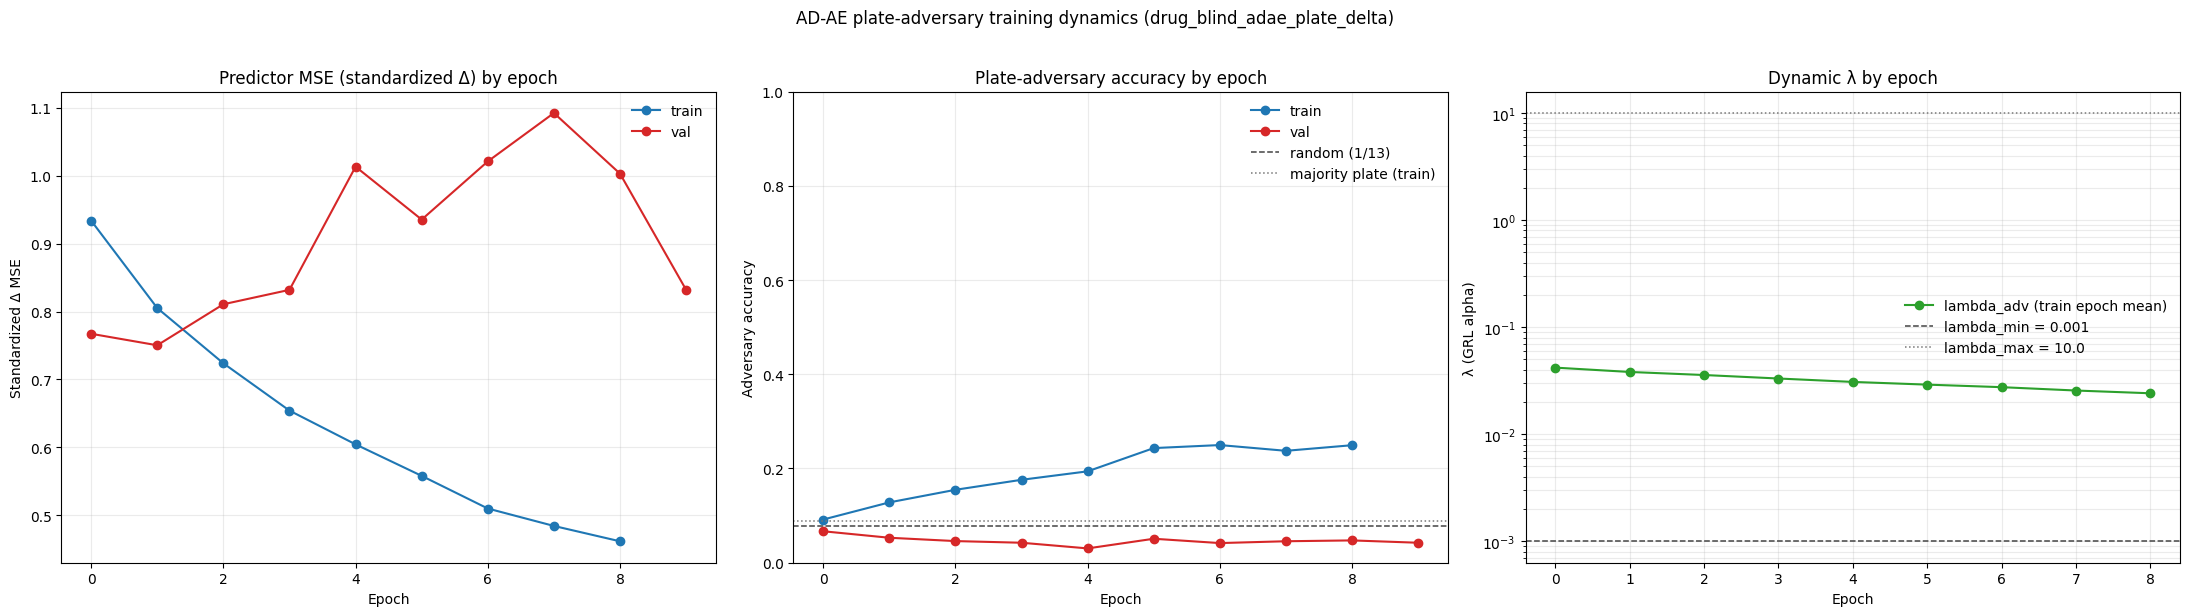

Final val_adv_acc = 0.042 is within ±0.05 of random (0.077). Plate is no longer linearly decodable from z_fused — deconfounding objective converged.


In [12]:
lightning_metrics_df = load_lightning_metrics_table(metrics_csv_path)


def _collapse_per_epoch(metrics_df, column):
    if column not in metrics_df.columns:
        return pd.DataFrame(columns=["epoch", column])
    subset = metrics_df.loc[metrics_df[column].notna(), ["epoch", column]].copy()
    if subset.empty:
        return subset
    subset["epoch"] = subset["epoch"].astype(int)
    return subset.groupby("epoch", as_index=False)[column].last()


panel_series_frames = {
    ("train", "predictor_mse_std"): _collapse_per_epoch(lightning_metrics_df, "train_predictor_mse_std"),
    ("val", "predictor_mse_std"): _collapse_per_epoch(lightning_metrics_df, "val_predictor_mse_std"),
    ("train", "adv_acc"): _collapse_per_epoch(lightning_metrics_df, "train_adv_acc"),
    ("val", "adv_acc"): _collapse_per_epoch(lightning_metrics_df, "val_adv_acc"),
    ("train", "lambda_adv"): _collapse_per_epoch(lightning_metrics_df, "train_lambda_adv"),
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
loss_ax, adv_ax, lambda_ax = axes

for split_name, color in (("train", "#1f77b4"), ("val", "#d62728")):
    series = panel_series_frames[(split_name, "predictor_mse_std")]
    if not series.empty:
        loss_ax.plot(
            series["epoch"],
            series[f"{split_name}_predictor_mse_std"],
            marker="o",
            color=color,
            label=split_name,
        )
loss_ax.set_title("Predictor MSE (standardized Δ) by epoch")
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Standardized Δ MSE")
loss_ax.grid(True, alpha=0.25)
loss_ax.legend(frameon=False)

for split_name, color in (("train", "#1f77b4"), ("val", "#d62728")):
    series = panel_series_frames[(split_name, "adv_acc")]
    if not series.empty:
        adv_ax.plot(
            series["epoch"],
            series[f"{split_name}_adv_acc"],
            marker="o",
            color=color,
            label=split_name,
        )
adv_ax.axhline(
    1.0 / n_confounder_classes,
    color="#444444",
    linestyle="--",
    linewidth=1.1,
    label=f"random (1/{n_confounder_classes})",
)
adv_ax.axhline(
    majority_baselines.get("train", float("nan")),
    color="#777777",
    linestyle=":",
    linewidth=1.1,
    label="majority plate (train)",
)
adv_ax.set_title("Plate-adversary accuracy by epoch")
adv_ax.set_xlabel("Epoch")
adv_ax.set_ylabel("Adversary accuracy")
adv_ax.set_ylim(0, 1)
adv_ax.grid(True, alpha=0.25)
adv_ax.legend(frameon=False)

lambda_series = panel_series_frames[("train", "lambda_adv")]
if not lambda_series.empty:
    lambda_ax.plot(
        lambda_series["epoch"],
        lambda_series["train_lambda_adv"],
        marker="o",
        color="#2ca02c",
        label="lambda_adv (train epoch mean)",
    )
lambda_ax.axhline(LAMBDA_MIN, color="#444444", linestyle="--", linewidth=1.1, label=f"lambda_min = {LAMBDA_MIN}")
lambda_ax.axhline(LAMBDA_MAX, color="#777777", linestyle=":", linewidth=1.1, label=f"lambda_max = {LAMBDA_MAX}")
if LAMBDA_MIN > 0 and LAMBDA_MAX > 0:
    lambda_ax.set_yscale("log")
lambda_ax.set_title("Dynamic λ by epoch")
lambda_ax.set_xlabel("Epoch")
lambda_ax.set_ylabel("λ (GRL alpha)")
lambda_ax.grid(True, alpha=0.25, which="both")
lambda_ax.legend(frameon=False)

fig.suptitle(f"AD-AE plate-adversary training dynamics ({run_name})", y=1.02)
fig.tight_layout()
plt.show()

val_adv_series = panel_series_frames[("val", "adv_acc")]
if not val_adv_series.empty:
    final_val_adv = float(val_adv_series["val_adv_acc"].iloc[-1])
    random_ref = 1.0 / n_confounder_classes
    majority_ref = majority_baselines.get("val", float("nan"))
    near_random = abs(final_val_adv - random_ref) <= 0.05
    if near_random:
        print(
            f"Final val_adv_acc = {final_val_adv:.3f} is within ±0.05 of random ({random_ref:.3f}). "
            "Plate is no longer linearly decodable from z_fused — deconfounding objective converged."
        )
    elif final_val_adv > max(0.85, majority_ref + 0.10):
        warnings.warn(
            f"Final val_adv_acc = {final_val_adv:.3f} is well above the majority plate baseline "
            f"({majority_ref:.3f}). GRL may be clipped at LAMBDA_MIN or encoder lacks capacity to "
            "fool the adversary."
        )

## Per-Plate Evaluation

The deconfounding claim is that per-plate metric variance should **drop** relative to a
no-adversary run (see the λ=0 ablation below). We aggregate test-set `treated_cosine` and
`delta_mse` per plate and compute the cross-plate mean and variance. A plate with few test
rows is flagged but not dropped — the λ=0 vs λ>0 comparison uses the same rows on both sides
so sample-size artifacts cancel.

,plate,n_rows,mean_treated_cosine,std_treated_cosine,mean_delta_mse,std_delta_mse
0,plate10,191,0.988207,0.009328,432.543307,660.148190
1,plate12,192,0.987451,0.009608,766.894598,1341.147092
2,plate13,215,0.987274,0.007431,376.439788,581.995936
3,plate1,168,0.986627,0.006173,799.161964,1096.970877
4,plate4,288,0.984533,0.008251,470.624387,748.809567
5,plate11,191,0.983946,0.013226,346.931077,342.976115
6,plate2,168,0.981446,0.009309,2378.334052,3536.304203
7,plate6,288,0.976707,0.019505,1192.143678,1856.795192
8,plate7,229,0.974440,0.045694,582.031010,1012.892396
9,plate9,224,0.973564,0.038782,462.109655,612.793578


,n_plates,treated_cosine_mean_of_plate_means,treated_cosine_std_of_plate_means,treated_cosine_var_of_plate_means,treated_cosine_range_of_plate_means,delta_mse_mean_of_plate_means,delta_mse_std_of_plate_means,delta_mse_var_of_plate_means,delta_mse_range_of_plate_means
0,13,0.978891,0.008517,0.000073,0.026088,760.836915,543.527558,295422.206723,2031.402975


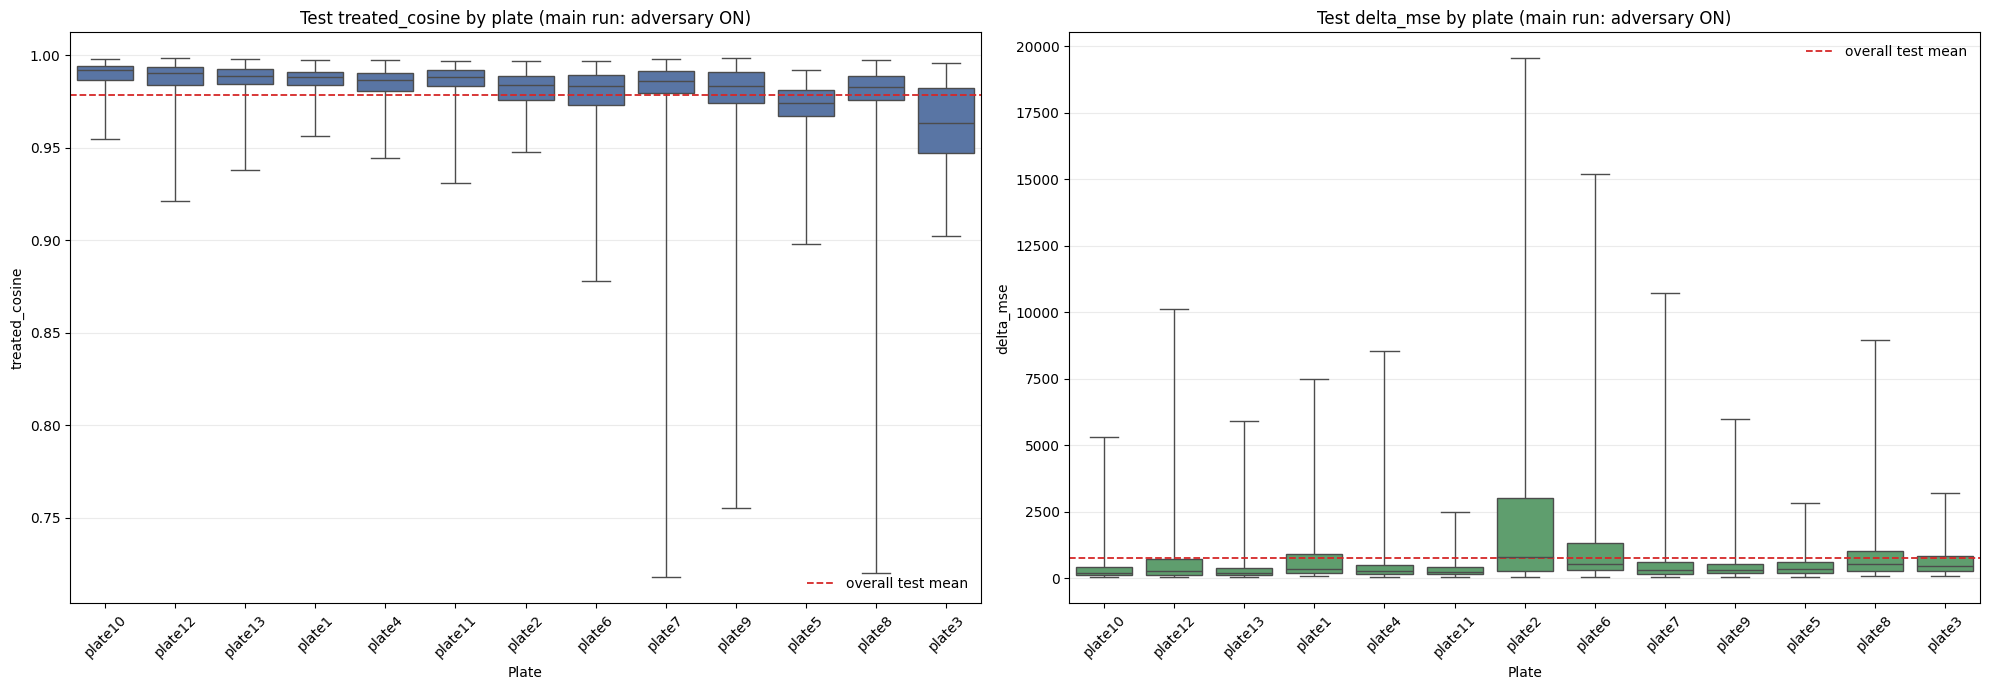

In [13]:
def summarize_per_plate(prediction_details_df, plate_column=CONFOUNDER_COLUMN):
    grouped = prediction_details_df.groupby(plate_column, as_index=False).agg(
        n_rows=("condition_key", "size"),
        mean_treated_cosine=("treated_cosine", "mean"),
        std_treated_cosine=("treated_cosine", "std"),
        mean_delta_mse=("delta_mse", "mean"),
        std_delta_mse=("delta_mse", "std"),
    )
    return grouped.sort_values("mean_treated_cosine", ascending=False, ignore_index=True)


def plate_variance_summary(per_plate_df):
    return pd.DataFrame(
        [
            {
                "n_plates": int(per_plate_df.shape[0]),
                "treated_cosine_mean_of_plate_means": float(per_plate_df["mean_treated_cosine"].mean()),
                "treated_cosine_std_of_plate_means": float(per_plate_df["mean_treated_cosine"].std()),
                "treated_cosine_var_of_plate_means": float(per_plate_df["mean_treated_cosine"].var()),
                "treated_cosine_range_of_plate_means": float(
                    per_plate_df["mean_treated_cosine"].max() - per_plate_df["mean_treated_cosine"].min()
                ),
                "delta_mse_mean_of_plate_means": float(per_plate_df["mean_delta_mse"].mean()),
                "delta_mse_std_of_plate_means": float(per_plate_df["mean_delta_mse"].std()),
                "delta_mse_var_of_plate_means": float(per_plate_df["mean_delta_mse"].var()),
                "delta_mse_range_of_plate_means": float(
                    per_plate_df["mean_delta_mse"].max() - per_plate_df["mean_delta_mse"].min()
                ),
            }
        ]
    )


main_per_plate_df = summarize_per_plate(test_prediction_details_df)
main_plate_variance_df = plate_variance_summary(main_per_plate_df)

display(main_per_plate_df)
display(main_plate_variance_df)

plate_order = main_per_plate_df[CONFOUNDER_COLUMN].tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cosine_ax, mse_ax = axes

sns.boxplot(
    data=test_prediction_details_df,
    x=CONFOUNDER_COLUMN,
    y="treated_cosine",
    order=plate_order,
    whis=(0, 100),
    color="#4c72b0",
    ax=cosine_ax,
)
cosine_ax.axhline(
    float(test_prediction_details_df["treated_cosine"].mean()),
    color="#d62728",
    linestyle="--",
    linewidth=1.3,
    label="overall test mean",
)
cosine_ax.set_title("Test treated_cosine by plate (main run: adversary ON)")
cosine_ax.set_xlabel("Plate")
cosine_ax.set_ylabel("treated_cosine")
cosine_ax.grid(True, axis="y", alpha=0.25)
cosine_ax.tick_params(axis="x", rotation=45)
cosine_ax.legend(frameon=False, loc="lower right")

sns.boxplot(
    data=test_prediction_details_df,
    x=CONFOUNDER_COLUMN,
    y="delta_mse",
    order=plate_order,
    whis=(0, 100),
    color="#55a868",
    ax=mse_ax,
)
mse_ax.axhline(
    float(test_prediction_details_df["delta_mse"].mean()),
    color="#d62728",
    linestyle="--",
    linewidth=1.3,
    label="overall test mean",
)
mse_ax.set_title("Test delta_mse by plate (main run: adversary ON)")
mse_ax.set_xlabel("Plate")
mse_ax.set_ylabel("delta_mse")
mse_ax.grid(True, axis="y", alpha=0.25)
mse_ax.tick_params(axis="x", rotation=45)
mse_ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

## Post-Training Linear Plate Probe on `z_fused`

Freeze the trained encoder, extract `z_fused` on train and test, and fit a linear
`LogisticRegression` probe to predict plate. This is the supervised-downstream mirror of the
pre-training plate probe: if deconfounding worked, the probe accuracy on test should drop
toward the random baseline (`1/n_plates`) relative to the pre-training number. If it instead
sits near the train-majority baseline the latent still encodes plate and the adversary is not
doing its job.

In [14]:
post_training_probe_result = probe_latent_plate_accuracy(
    response_model,
    fit_dataloader=response_data_module.train_eval_dataloader(),
    eval_dataloader=response_data_module.test_dataloader(),
    confounder_key="confounder_index",
    random_state=RANDOM_SEED,
)
post_training_probe_df = pd.DataFrame([{"run": "main_adversary_on", **post_training_probe_result}])
display(post_training_probe_df)

main_probe_accuracy = float(post_training_probe_result["probe_accuracy"])
main_probe_random = float(post_training_probe_result["random_baseline"])
main_probe_majority = float(post_training_probe_result["majority_baseline"])
print(
    f"Post-training linear plate probe on z_fused (test): accuracy = {main_probe_accuracy:.3f} "
    f"vs random = {main_probe_random:.3f} / majority = {main_probe_majority:.3f}."
)
if main_probe_accuracy <= main_probe_random + 0.05:
    print(
        "Probe accuracy is at the random baseline → plate is not linearly decodable from z_fused "
        "after adversarial training. This is the intended deconfounding outcome."
    )
elif main_probe_accuracy >= max(main_probe_majority, 0.6):
    warnings.warn(
        f"Post-training probe accuracy ({main_probe_accuracy:.3f}) is still at or above the majority "
        f"plate baseline ({main_probe_majority:.3f}). The adversary did not suppress plate in z_fused; "
        "consider raising LAMBDA_MAX or ALPHA_TARGET, or training longer."
    )

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,run,probe_accuracy,random_baseline,majority_baseline,n_train_samples,n_eval_samples,n_train_classes,n_eval_classes,latent_dim
0,main_adversary_on,0.255462,0.076923,0.067653,22636,2838,13,13,256


Post-training linear plate probe on z_fused (test): accuracy = 0.255 vs random = 0.077 / majority = 0.068.


## PCA of `z_fused` Colored by Plate

Visual evidence for the same claim. PCA is fit on the **test** `z_fused` matrix; if the
adversary worked, plate clusters should be visibly weaker than they would be without the
adversary. (We repeat this plot for the ablation run below so the two are directly
comparable.)

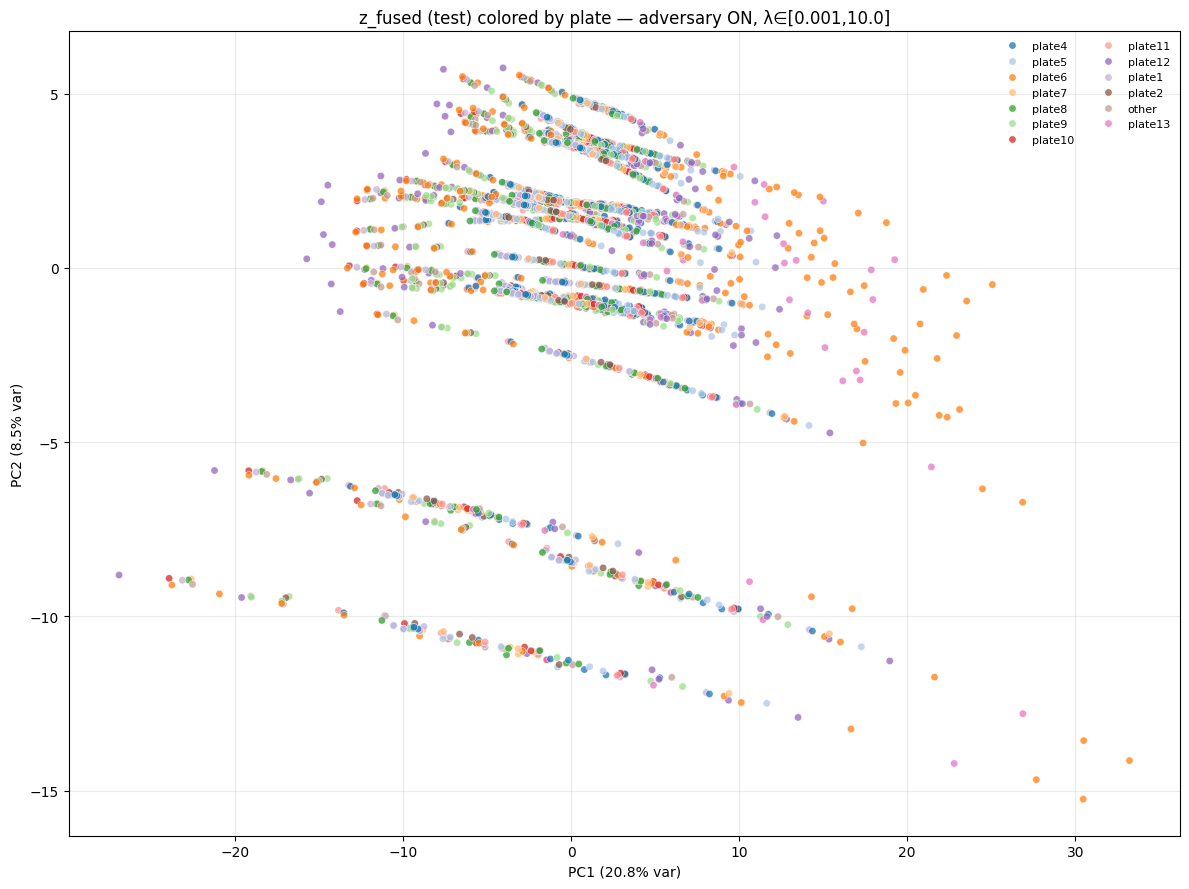

In [15]:
def collect_z_fused_with_plate(model, dataset):
    model.eval()
    gene_list, drug_list, dose_list, plate_list = [], [], [], []
    for idx in range(len(dataset)):
        example = dataset[idx]
        gene_list.append(example["gene_features"])
        drug_list.append(example["drug_features"])
        dose_list.append(example["dose_feature"])
        plate_list.append(dataset.confounder_values[idx] if dataset.confounder_values is not None else None)
    stacked_inputs = {
        "gene_features": torch.stack(gene_list, dim=0),
        "drug_features": torch.stack(drug_list, dim=0),
        "dose_feature": torch.stack(dose_list, dim=0),
    }
    with torch.no_grad():
        _, _, z_fused = model.latent_embeddings(stacked_inputs)
    return z_fused.detach().cpu().numpy(), np.asarray(plate_list)


def plot_z_fused_pca_by_plate(model, dataset, title_suffix):
    z_fused_np, plate_arr = collect_z_fused_with_plate(model, dataset)
    pca_fused = PCA(n_components=2, svd_solver="full").fit(z_fused_np)
    z_fused_2d = pca_fused.transform(z_fused_np)
    plot_df = pd.DataFrame(
        {
            "pc1": z_fused_2d[:, 0],
            "pc2": z_fused_2d[:, 1],
            CONFOUNDER_COLUMN: plate_arr,
        }
    )
    plate_counts = plot_df[CONFOUNDER_COLUMN].value_counts()
    legend_plates = plate_counts.index[:12].tolist()
    plot_df["plate_legend"] = plot_df[CONFOUNDER_COLUMN].where(
        plot_df[CONFOUNDER_COLUMN].isin(legend_plates), other="other"
    )

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.scatterplot(
        data=plot_df,
        x="pc1",
        y="pc2",
        hue="plate_legend",
        s=28,
        alpha=0.75,
        ax=ax,
        palette="tab20",
    )
    ax.set_title(f"z_fused (test) colored by plate — {title_suffix}")
    ax.set_xlabel(f"PC1 ({pca_fused.explained_variance_ratio_[0] * 100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca_fused.explained_variance_ratio_[1] * 100:.1f}% var)")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, loc="best", fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()
    return z_fused_np, plate_arr, pca_fused.explained_variance_ratio_


main_z_fused_test, main_plate_test_arr, main_pca_explained = plot_z_fused_pca_by_plate(
    response_model,
    response_data_module.test_dataset,
    title_suffix=f"adversary ON, λ∈[{LAMBDA_MIN},{LAMBDA_MAX}]",
)

## λ=0 Ablation Control Run (adversary disabled)

Retrain the same architecture with `LAMBDA_MIN = LAMBDA_MAX = 0.0`, which clamps the GRL
alpha to zero. The FiLM fuser and drug-conditioned adversary input are still present, so the
only thing being ablated is reversed-gradient pressure from the adversary onto the encoders.
The adversary head is still optimized (so `val_adv_acc` remains a meaningful probe of how
plate-decodable the latent is) but it exerts **no** reversed gradient pressure on the
encoders. All other knobs (seed, architecture, split, preprocessor, optimizer, scheduler,
max epochs) are held fixed. This is the control for the deconfounding claim:

- If the main run and the ablation run have comparable predictor quality but the main run
  has lower per-plate variance and a lower post-training plate probe accuracy, the adversary
  is doing what it's supposed to do.
- If predictor quality collapses in the main run relative to the ablation, the adversary is
  over-constrained — lower `ALPHA_TARGET` or tighten `LAMBDA_MAX`.

In [16]:
L.seed_everything(RANDOM_SEED, workers=True)

ablation_run_name = f"{run_name}_ablation_lambda0"
ablation_run_config = {**run_config, "LAMBDA_MIN": 0.0, "LAMBDA_MAX": 0.0}
ablation_lightning_output_dir = build_project_path(LIGHTNING_OUTPUT_DIR)
ablation_lightning_output_dir.mkdir(parents=True, exist_ok=True)
ablation_csv_logger = CSVLogger(save_dir=str(ablation_lightning_output_dir), name=ablation_run_name)
ablation_checkpoint_dir = ablation_lightning_output_dir / ablation_run_name / "checkpoints"
ablation_checkpoint_dir.mkdir(parents=True, exist_ok=True)

ablation_data_module = DrugResponseDataModule(
    train_examples_df=train_examples_df,
    val_examples_df=val_examples_df,
    test_examples_df=test_examples_df,
    preprocessor=training_preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=RANDOM_SEED,
    confounder_column=CONFOUNDER_COLUMN,
    confounder_to_index=plate_to_index,
)
ablation_data_module.setup()

ablation_model = build_model(
    MODEL_NAME,
    gene_dim=target_gene_dim,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    delta_mean=training_preprocessor.delta_mean,
    delta_std=training_preprocessor.delta_std,
    input_gene_dim=training_preprocessor.input_gene_dim,
    drug_feature_dim=training_preprocessor.fingerprint_dim,
    dose_feature_dim=1,
    ctx_branch_hidden_dims=CTX_BRANCH_HIDDEN_DIMS,
    drug_branch_hidden_dims=DRUG_BRANCH_HIDDEN_DIMS,
    z_ctx_dim=Z_CTX_DIM,
    z_drug_dim=Z_DRUG_DIM,
    fused_hidden_dims=FUSED_HIDDEN_DIMS,
    predictor_hidden_dims=PREDICTOR_HIDDEN_DIMS,
    adv_hidden_dims=ADV_HIDDEN_DIMS,
    n_confounder_classes=n_confounder_classes,
    alpha_target=ALPHA_TARGET,
    ema_momentum=EMA_MOMENTUM,
    lambda_min=0.0,
    lambda_max=0.0,
    fuser_type=FUSER_TYPE,
    adversary_conditioning=ADVERSARY_CONDITIONING,
)

ablation_monitor_placeholder = (
    f"{EARLY_STOPPING_MONITOR}=" + "{" + EARLY_STOPPING_MONITOR + ":.6f}"
)
ablation_checkpoint_callback = ModelCheckpoint(
    dirpath=str(ablation_checkpoint_dir),
    filename="epoch={epoch:02d}-" + ablation_monitor_placeholder,
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    save_top_k=1,
)
ablation_early_stopping_callback = EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    patience=EARLY_STOPPING_PATIENCE,
)

ablation_trainer = L.Trainer(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    precision=PRECISION,
    max_epochs=MAX_EPOCHS,
    logger=ablation_csv_logger,
    callbacks=[ablation_checkpoint_callback, ablation_early_stopping_callback],
    log_every_n_steps=max(1, math.ceil(len(train_examples_df) / BATCH_SIZE / 10)),
    deterministic=False,
)

ablation_trainer.fit(ablation_model, datamodule=ablation_data_module)
ablation_val_results = ablation_trainer.validate(
    ablation_model, datamodule=ablation_data_module, ckpt_path="best", verbose=False
)
ablation_test_results = ablation_trainer.test(
    ablation_model, datamodule=ablation_data_module, ckpt_path="best", verbose=False
)

ablation_best_model_path = ablation_checkpoint_callback.best_model_path
if not ablation_best_model_path:
    raise ValueError("Lightning did not produce a best checkpoint path for the ablation run.")
ablation_best_checkpoint_state = torch.load(ablation_best_model_path, map_location="cpu")
ablation_model.load_state_dict(ablation_best_checkpoint_state["state_dict"])
ablation_metrics_csv_path = Path(ablation_csv_logger.log_dir) / "metrics.csv"
ablation_training_run_summary_path = Path(ablation_csv_logger.log_dir) / "training_run_summary.json"

ablation_evaluation_rows = []
ablation_prediction_detail_tables = {}
ablation_loaders = {
    "train": ablation_data_module.train_eval_dataloader(),
    "val": ablation_data_module.val_dataloader(),
    "test": ablation_data_module.test_dataloader(),
}
for split_name, loader in ablation_loaders.items():
    metrics_row, _, prediction_details_df = evaluate_model_on_loader(
        model=ablation_model,
        loader=loader,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    ablation_evaluation_rows.append(metrics_row)
    merged = prediction_details_df.merge(
        plate_lookup_frames[split_name],
        on="condition_key",
        how="left",
        validate="many_to_one",
    )
    if merged[CONFOUNDER_COLUMN].isna().any():
        raise ValueError(
            f"Failed to backfill '{CONFOUNDER_COLUMN}' onto ablation {split_name} prediction details."
        )
    ablation_prediction_detail_tables[split_name] = merged

ablation_evaluation_summary_df = pd.DataFrame(ablation_evaluation_rows)
ablation_test_prediction_details_df = ablation_prediction_detail_tables["test"].copy()

ablation_probe_result = probe_latent_plate_accuracy(
    ablation_model,
    fit_dataloader=ablation_data_module.train_eval_dataloader(),
    eval_dataloader=ablation_data_module.test_dataloader(),
    confounder_key="confounder_index",
    random_state=RANDOM_SEED,
)

ablation_run_summary_df = pd.DataFrame(
    [
        {
            **ablation_run_config,
            "ablation_best_model_path": str(ablation_best_model_path),
            "ablation_metrics_csv_path": str(ablation_metrics_csv_path),
            "ablation_training_run_summary_path": str(ablation_training_run_summary_path),
            "ablation_best_monitor_value": float(ablation_checkpoint_callback.best_model_score.item()),
            "monitor": EARLY_STOPPING_MONITOR,
            "ablation_run_name": ablation_run_name,
            "ablation_current_epoch": int(ablation_trainer.current_epoch),
            "ablation_final_lambda_adv": float(ablation_model.grl.alpha),
        }
    ]
)
ablation_training_run_summary_path.write_text(ablation_run_summary_df.to_json(orient="records", indent=2))

display(ablation_run_summary_df)
display(ablation_evaluation_summary_df)
display(pd.DataFrame([{"run": "ablation_lambda0", **ablation_probe_result}]))

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder_ctx    │ Sequential            │ 43.3 M │ train │     0 │
│ 1 │ encoder_drug   │ Sequential            │  1.1 M │ train │     0 │
│ 2 │ fuser          │ Sequential            │  230 K │ train │     0 │
│ 3 │ predictor_head │ Sequential            │  632 K │ train │     0 │
│ 4 │ grl            │ GradientReversalLayer │      0 │ train │     0 │
│ 5 │ adversary_head │ Sequential            │ 37.1 K │ train │     0 │
└───┴────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 45.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 45.3 M                                                                                               
Total estimated model params size (MB): 181                                                                        
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities
/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta_ablation_lambda0/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979619.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae_plate/drug_blind_adae_plate_delta_ablation_lambda0/checkpoints/epoch=epoch=03-val_treated_cosine=val_treated_cosine=0.979619.ckpt
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,ablation_best_model_path,ablation_metrics_csv_path,ablation_best_monitor_value,monitor,ablation_run_name,ablation_current_epoch,ablation_final_lambda_adv
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/dl_fin/deep-learning-final-p...,0.979619,val_treated_cosine,drug_blind_adae_plate_delta_ablation_lambda0,9,0.0


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction,top50_deg_match_count_mean,top50_deg_match_count_median,top50_deg_match_fraction_mean,top50_deg_match_fraction_median,signed_ndcg_at_50_mean,signed_ndcg_at_50_median
0,train,22636,445.277607,6.708413,0.978239,479288.5,0.378291,0.327438,0.780703,29.061186,29.0,0.581224,0.58,0.697098,0.740500
1,val,2830,630.189283,8.749076,0.979619,487695.0,0.204001,0.039616,0.479859,25.950530,25.0,0.519011,0.50,0.562148,0.610067
2,test,2838,738.337831,9.426083,0.978574,483409.0,0.195064,0.030306,0.458421,24.935870,25.0,0.498717,0.50,0.523333,0.561625


,run,probe_accuracy,random_baseline,majority_baseline,n_train_samples,n_eval_samples,n_train_classes,n_eval_classes,latent_dim
0,ablation_lambda0,0.240662,0.076923,0.067653,22636,2838,13,13,256


## Main vs Ablation: Per-Plate Variance and Probe Accuracy

Overlay the per-plate `treated_cosine` and `delta_mse` distributions from the two runs and
summarize the cross-plate variance. This is the figure the write-up needs: if the
adversary helped, the blue (adversary ON) boxes are tighter across plates than the orange
(adversary OFF) boxes, and the scalar `var_of_plate_means` is lower on the left side of the
table.

,run,n_plates,treated_cosine_mean_of_plate_means,treated_cosine_std_of_plate_means,treated_cosine_var_of_plate_means,treated_cosine_range_of_plate_means,delta_mse_mean_of_plate_means,delta_mse_std_of_plate_means,delta_mse_var_of_plate_means,delta_mse_range_of_plate_means
0,main_adversary_on,13,0.978891,0.008517,0.000073,0.026088,760.836915,543.527558,295422.206723,2031.402975
1,ablation_lambda0,13,0.978828,0.008490,0.000072,0.026279,759.766332,527.461605,278215.744336,1981.941467


,run,probe_accuracy,random_baseline,majority_baseline,n_train_samples,n_eval_samples,n_train_classes,n_eval_classes,latent_dim
0,main_adversary_on,0.255462,0.076923,0.067653,22636,2838,13,13,256
1,ablation_lambda0,0.240662,0.076923,0.067653,22636,2838,13,13,256


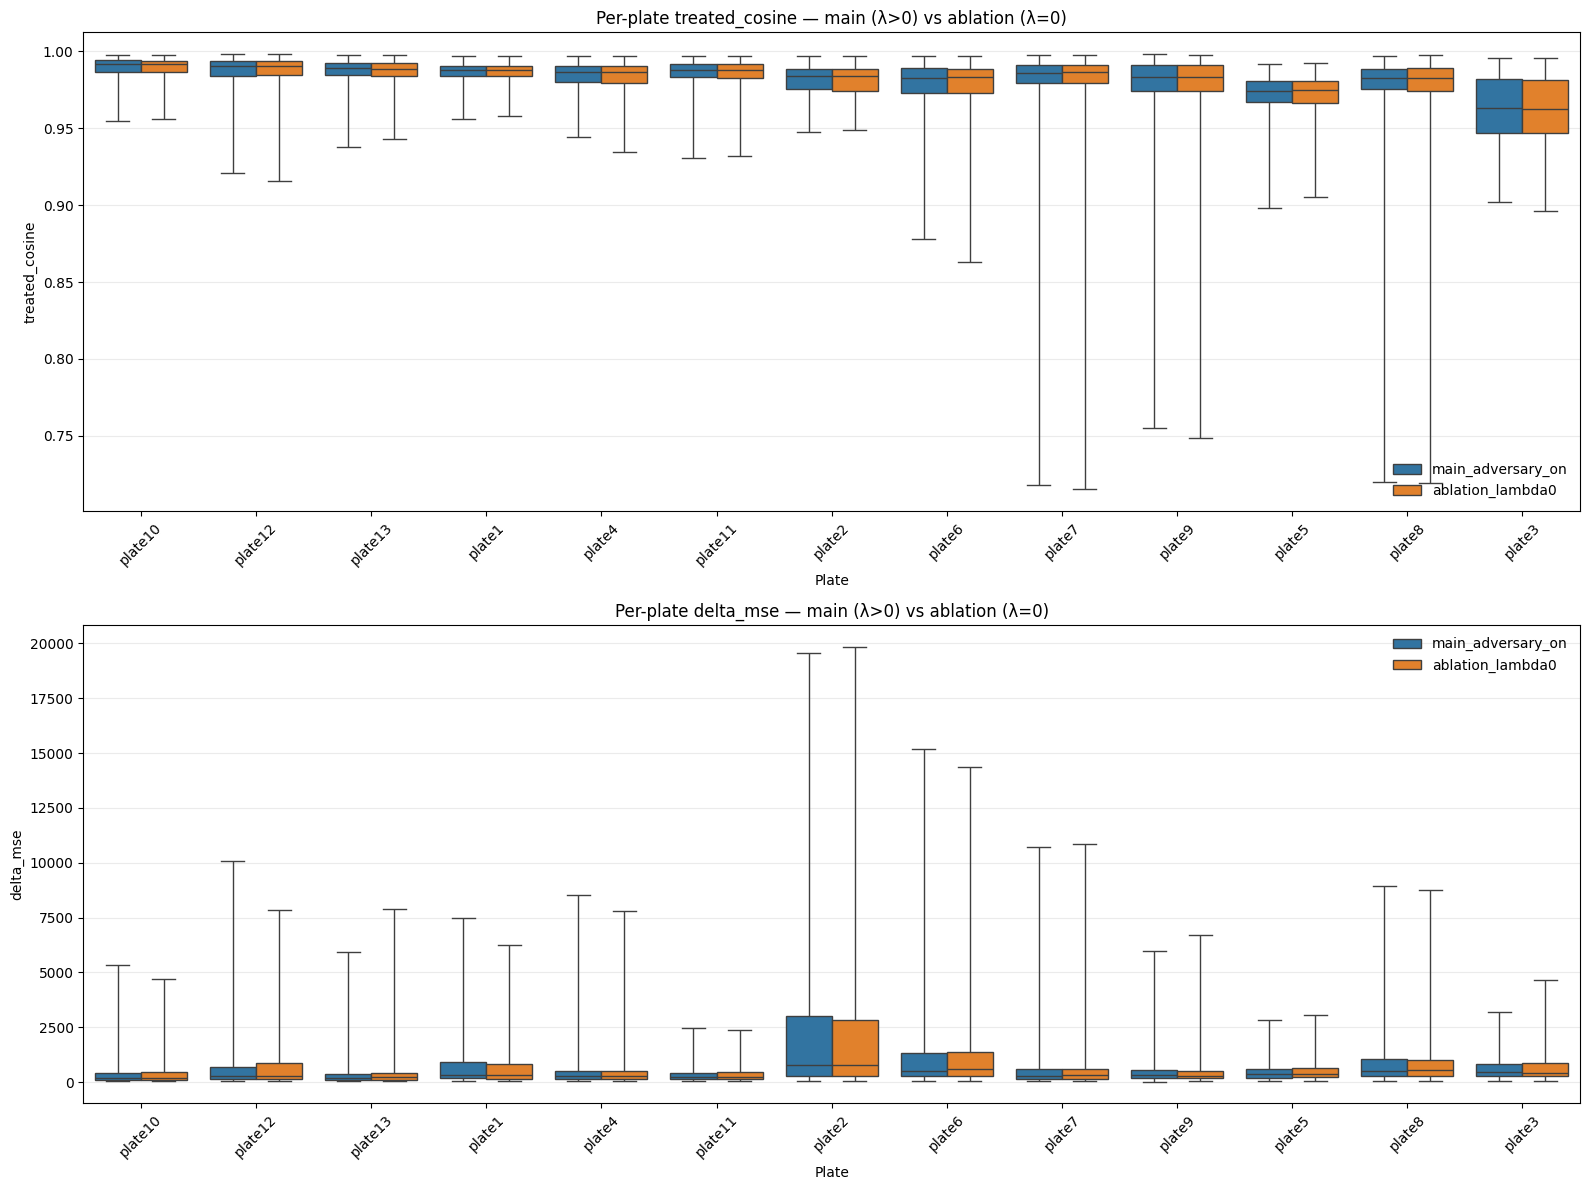

,metric,main_adversary_on,ablation_lambda0,main_minus_ablation
0,treated_cosine_var_of_plate_means,0.000073,0.000072,4.642406e-07
1,delta_mse_var_of_plate_means,295422.206723,278215.744336,1.720646e+04
2,post_training_plate_probe_accuracy,0.255462,0.240662,1.479915e-02
3,test_treated_cosine_mean,0.978635,0.978574,6.054051e-05
4,test_delta_mse_mean,738.571463,738.337831,2.336317e-01


Deconfounding headline numbers (lower variance + lower probe accuracy = adversary working; test treated_cosine should stay within noise of the ablation):
  treated_cosine_var_of_plate_means           main = 7.2542e-05  ablation = 7.2078e-05  Δ = +4.6424e-07
  delta_mse_var_of_plate_means                main = 2.9542e+05  ablation = 2.7822e+05  Δ = +1.7206e+04
  post_training_plate_probe_accuracy          main = 2.5546e-01  ablation = 2.4066e-01  Δ = +1.4799e-02
  test_treated_cosine_mean                    main = 9.7863e-01  ablation = 9.7857e-01  Δ = +6.0541e-05
  test_delta_mse_mean                         main = 7.3857e+02  ablation = 7.3834e+02  Δ = +2.3363e-01


In [17]:
ablation_per_plate_df = summarize_per_plate(ablation_test_prediction_details_df)
ablation_plate_variance_df = plate_variance_summary(ablation_per_plate_df)

comparison_variance_df = pd.concat(
    [
        main_plate_variance_df.assign(run="main_adversary_on"),
        ablation_plate_variance_df.assign(run="ablation_lambda0"),
    ],
    ignore_index=True,
)
comparison_variance_df = comparison_variance_df[
    ["run", *[c for c in comparison_variance_df.columns if c != "run"]]
]
display(comparison_variance_df)

comparison_probe_df = pd.DataFrame(
    [
        {"run": "main_adversary_on", **post_training_probe_result},
        {"run": "ablation_lambda0", **ablation_probe_result},
    ]
)
display(comparison_probe_df)

main_overall_df = test_prediction_details_df[["condition_key", CONFOUNDER_COLUMN, "treated_cosine", "delta_mse"]].assign(
    run="main_adversary_on"
)
ablation_overall_df = ablation_test_prediction_details_df[
    ["condition_key", CONFOUNDER_COLUMN, "treated_cosine", "delta_mse"]
].assign(run="ablation_lambda0")
overlay_df = pd.concat([main_overall_df, ablation_overall_df], ignore_index=True)

comparison_plate_order = (
    main_per_plate_df.sort_values("mean_treated_cosine", ascending=False)[CONFOUNDER_COLUMN].tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
cosine_ax, mse_ax = axes

sns.boxplot(
    data=overlay_df,
    x=CONFOUNDER_COLUMN,
    y="treated_cosine",
    hue="run",
    order=comparison_plate_order,
    whis=(0, 100),
    palette={"main_adversary_on": "#1f77b4", "ablation_lambda0": "#ff7f0e"},
    ax=cosine_ax,
)
cosine_ax.set_title("Per-plate treated_cosine — main (λ>0) vs ablation (λ=0)")
cosine_ax.set_xlabel("Plate")
cosine_ax.set_ylabel("treated_cosine")
cosine_ax.grid(True, axis="y", alpha=0.25)
cosine_ax.tick_params(axis="x", rotation=45)
cosine_ax.legend(frameon=False, loc="lower right")

sns.boxplot(
    data=overlay_df,
    x=CONFOUNDER_COLUMN,
    y="delta_mse",
    hue="run",
    order=comparison_plate_order,
    whis=(0, 100),
    palette={"main_adversary_on": "#1f77b4", "ablation_lambda0": "#ff7f0e"},
    ax=mse_ax,
)
mse_ax.set_title("Per-plate delta_mse — main (λ>0) vs ablation (λ=0)")
mse_ax.set_xlabel("Plate")
mse_ax.set_ylabel("delta_mse")
mse_ax.grid(True, axis="y", alpha=0.25)
mse_ax.tick_params(axis="x", rotation=45)
mse_ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

summary_comparison_df = pd.DataFrame(
    [
        {
            "metric": "treated_cosine_var_of_plate_means",
            "main_adversary_on": float(main_plate_variance_df["treated_cosine_var_of_plate_means"].iloc[0]),
            "ablation_lambda0": float(ablation_plate_variance_df["treated_cosine_var_of_plate_means"].iloc[0]),
        },
        {
            "metric": "delta_mse_var_of_plate_means",
            "main_adversary_on": float(main_plate_variance_df["delta_mse_var_of_plate_means"].iloc[0]),
            "ablation_lambda0": float(ablation_plate_variance_df["delta_mse_var_of_plate_means"].iloc[0]),
        },
        {
            "metric": "post_training_plate_probe_accuracy",
            "main_adversary_on": main_probe_accuracy,
            "ablation_lambda0": float(ablation_probe_result["probe_accuracy"]),
        },
        {
            "metric": "test_treated_cosine_mean",
            "main_adversary_on": float(evaluation_summary_df.loc[evaluation_summary_df["split"] == "test", "treated_cosine"].iloc[0]),
            "ablation_lambda0": float(
                ablation_evaluation_summary_df.loc[ablation_evaluation_summary_df["split"] == "test", "treated_cosine"].iloc[0]
            ),
        },
        {
            "metric": "test_delta_mse_mean",
            "main_adversary_on": float(evaluation_summary_df.loc[evaluation_summary_df["split"] == "test", "delta_mse"].iloc[0]),
            "ablation_lambda0": float(
                ablation_evaluation_summary_df.loc[ablation_evaluation_summary_df["split"] == "test", "delta_mse"].iloc[0]
            ),
        },
    ]
)
summary_comparison_df["main_minus_ablation"] = (
    summary_comparison_df["main_adversary_on"] - summary_comparison_df["ablation_lambda0"]
)
display(summary_comparison_df)

print(
    "Deconfounding headline numbers (lower variance + lower probe accuracy = adversary working; "
    "test treated_cosine should stay within noise of the ablation):"
)
for _, row in summary_comparison_df.iterrows():
    print(
        f"  {row['metric']:42s}  main = {row['main_adversary_on']:.4e}  "
        f"ablation = {row['ablation_lambda0']:.4e}  Δ = {row['main_minus_ablation']:+.4e}"
    )

## PCA of `z_fused`: Main vs Ablation

Same PCA recipe as the main-run plot, now applied to the ablation checkpoint. Side-by-side
visual sanity check: if the main run flattens plate clusters relative to the ablation, the
adversary is pulling plate structure out of `z_fused` as intended.

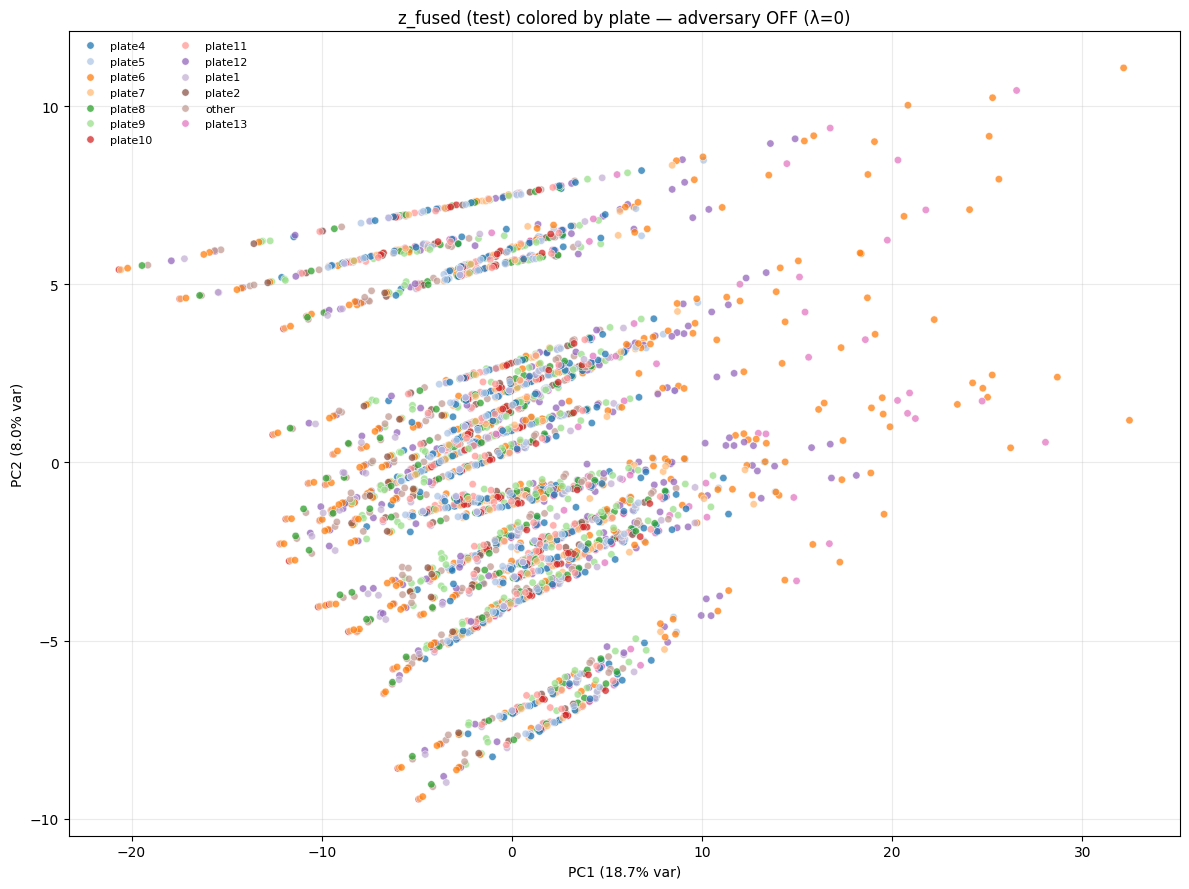

,plate,main_mean_norm,ablation_mean_norm,main_minus_ablation
0,plate1,8.198190,7.875670,0.322520
1,plate10,8.171638,7.938651,0.232987
2,plate11,8.209249,7.638250,0.570998
3,plate12,8.270190,7.809740,0.460451
4,plate13,7.970072,8.131159,-0.161087
5,plate2,8.111941,7.834739,0.277203
6,plate3,8.716020,8.261119,0.454901
7,plate4,7.801572,7.653090,0.148482
8,plate5,7.931187,7.601537,0.329650
9,plate6,8.535411,8.451977,0.083434


,run,mean_plate_centroid_norm,var_plate_centroid_norm
0,main_adversary_on,8.200329,0.064470
1,ablation_lambda0,7.881992,0.067122


Per-plate centroid norms in z_fused: smaller + tighter distribution → plate identity is less reflected in the mean embedding direction, which is what the adversary is trying to achieve.


In [18]:
ablation_z_fused_test, ablation_plate_test_arr, ablation_pca_explained = plot_z_fused_pca_by_plate(
    ablation_model,
    ablation_data_module.test_dataset,
    title_suffix="adversary OFF (λ=0)",
)

main_plate_mean_norms = {
    plate_name: float(np.linalg.norm(main_z_fused_test[main_plate_test_arr == plate_name].mean(axis=0)))
    for plate_name in np.unique(main_plate_test_arr)
}
ablation_plate_mean_norms = {
    plate_name: float(np.linalg.norm(ablation_z_fused_test[ablation_plate_test_arr == plate_name].mean(axis=0)))
    for plate_name in np.unique(ablation_plate_test_arr)
}
plate_mean_norm_df = pd.DataFrame(
    [
        {
            "plate": plate_name,
            "main_mean_norm": main_plate_mean_norms.get(plate_name, float("nan")),
            "ablation_mean_norm": ablation_plate_mean_norms.get(plate_name, float("nan")),
        }
        for plate_name in sorted(set(main_plate_mean_norms) | set(ablation_plate_mean_norms))
    ]
)
plate_mean_norm_df["main_minus_ablation"] = (
    plate_mean_norm_df["main_mean_norm"] - plate_mean_norm_df["ablation_mean_norm"]
)
display(plate_mean_norm_df)

plate_mean_norm_summary_df = pd.DataFrame(
    [
        {
            "run": "main_adversary_on",
            "mean_plate_centroid_norm": float(plate_mean_norm_df["main_mean_norm"].mean()),
            "var_plate_centroid_norm": float(plate_mean_norm_df["main_mean_norm"].var()),
        },
        {
            "run": "ablation_lambda0",
            "mean_plate_centroid_norm": float(plate_mean_norm_df["ablation_mean_norm"].mean()),
            "var_plate_centroid_norm": float(plate_mean_norm_df["ablation_mean_norm"].var()),
        },
    ]
)
display(plate_mean_norm_summary_df)
print(
    "Per-plate centroid norms in z_fused: smaller + tighter distribution → plate identity is "
    "less reflected in the mean embedding direction, which is what the adversary is trying to achieve."
)